In [2]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm  # <--- 에러 원인 해결

# 1. 시드 고정
random.seed(42)
torch.manual_seed(42)

# 2. 초경량 Siamese CNN 설계 (약 0.5M 파라미터)
class TinySiamese(nn.Module):
    def __init__(self):
        super(TinySiamese, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 5 * 5, 128) # 128차원 특징 벡터
        )

    def forward(self, img1, img2):
        out1 = self.feature_extractor(img1)
        out2 = self.feature_extractor(img2)
        # 두 벡터 사이의 유클리드 거리 (작을수록 비슷함)
        return torch.norm(out1 - out2, p=2, dim=1)

# 3. 데이터셋 구성 (쌍으로 데이터 매칭)
class SiameseMNIST(Dataset):
    def __init__(self, mnist_dataset):
        self.ds = mnist_dataset
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        if same:
            idx = random.randint(0, len(self.ds)-1)
            while self.ds[idx][1] != label1: idx = random.randint(0, len(self.ds)-1)
        else:
            idx = random.randint(0, len(self.ds)-1)
            while self.ds[idx][1] == label1: idx = random.randint(0, len(self.ds)-1)
        img2, label2 = self.ds[idx]
        return img1, img2, torch.tensor(1.0 if same else 0.0)

# 4. 학습 준비
device = "cuda" if torch.cuda.is_available() else "cpu"
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_ds = datasets.MNIST('./data', train=True, download=True, transform=transform)
siamese_ds = SiameseMNIST(train_ds)
loader = DataLoader(siamese_ds, batch_size=64, shuffle=True)

model = TinySiamese().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. 학습 루프
print("🚀 [Step 1] 모양 유사도 학습 시작...")
model.train()
for epoch in range(3):
    total_loss = 0
    for img1, img2, label in tqdm(loader):
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        
        # 거리 계산
        dist = model(img1, img2)
        
        # Contrastive Loss: 같은 숫자면 거리를 0으로, 다른 숫자면 거리를 1 이상으로
        loss = label * dist.pow(2) + (1 - label) * F.relu(1.0 - dist).pow(2)
        loss = loss.mean()
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} Loss: {total_loss/len(loader):.4f}")

# 6. [실전] 공정에서 부품 찾는 시뮬레이션
print("\n--- 🏁 모양 찾기 테스트 (Similarity Match) ---")
model.eval()
test_ds = datasets.MNIST('./data', train=False, transform=transform)

for i in range(5):
    # 1. 템플릿(정상 부품) 선정
    ref_img, ref_label = test_ds[i]
    
    # 2. 비교 대상(카메라에 찍힌 것) 선정
    target_idx = random.randint(0, 100)
    tar_img, tar_label = test_ds[target_idx]
    
    with torch.no_grad():
        # 두 이미지의 거리 계산
        distance = model(ref_img.unsqueeze(0).to(device), tar_img.unsqueeze(0).to(device)).item()
        
    result = "✅ 동일(MATCH)" if distance < 0.5 else "❌ 다름(MISMATCH)"
    print(f"기준[{ref_label}] vs 대상[{tar_label}] | 거리: {distance:.4f} | 결과: {result}")

🚀 [Step 1] 모양 유사도 학습 시작...


100%|██████████| 938/938 [01:32<00:00, 10.12it/s]


Epoch 1 Loss: 0.0950


100%|██████████| 938/938 [01:30<00:00, 10.37it/s]


Epoch 2 Loss: 0.0661


100%|██████████| 938/938 [01:29<00:00, 10.48it/s]

Epoch 3 Loss: 0.0610

--- 🏁 모양 찾기 테스트 (Similarity Match) ---
기준[7] vs 대상[9] | 거리: 1.0658 | 결과: ❌ 다름(MISMATCH)
기준[2] vs 대상[1] | 거리: 0.9912 | 결과: ❌ 다름(MISMATCH)
기준[1] vs 대상[6] | 거리: 0.9571 | 결과: ❌ 다름(MISMATCH)
기준[0] vs 대상[1] | 거리: 0.9309 | 결과: ❌ 다름(MISMATCH)
기준[4] vs 대상[0] | 거리: 1.1452 | 결과: ❌ 다름(MISMATCH)



--- 🏁 시각화 및 거리 분석 시작 ---
테스트 1: [2] vs [9] | 거리: 1.3682 | 결과: MISMATCH
테스트 2: [5] vs [3] | 거리: 0.6530 | 결과: MISMATCH
테스트 3: [8] vs [4] | 거리: 0.8720 | 결과: MISMATCH
테스트 4: [7] vs [8] | 거리: 1.1565 | 결과: MISMATCH
테스트 5: [0] vs [7] | 거리: 1.0061 | 결과: MISMATCH


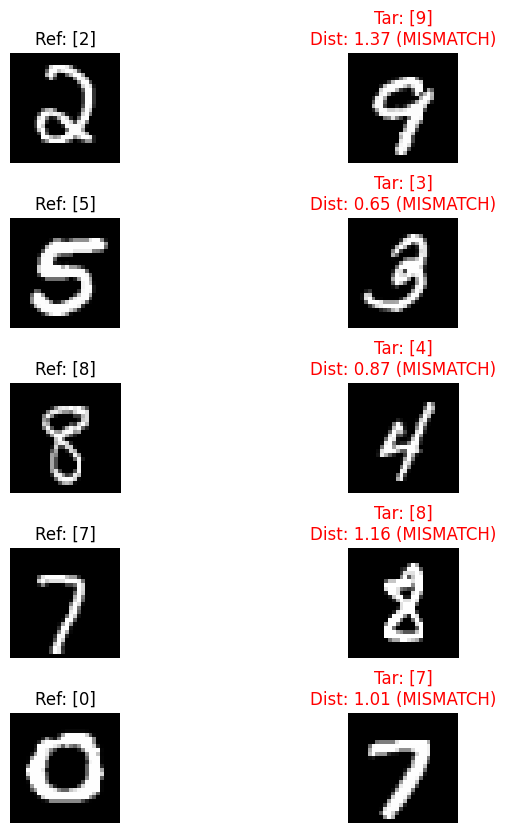

In [3]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt # <--- 시각화 라이브러리 추가

# 1~5. 학습 코드는 이전과 동일하므로 생략 없이 포함하여 실행해야 합니다.
# (이전 TinySiamese, SiameseMNIST, 학습 루프 코드를 여기에 넣어주세요)

# 6. [최종] 시각화 및 결과 분석 함수
def visualize_match(num_tests=5):
    model.eval()
    test_ds = datasets.MNIST('./data', train=False, transform=transform)
    
    # matplotlib 설정 (나란히 배치)
    fig, axes = plt.subplots(num_tests, 2, figsize=(8, 2 * num_tests))
    plt.subplots_adjust(hspace=0.5)

    print("\n--- 🏁 시각화 및 거리 분석 시작 ---")
    for i in range(num_tests):
        # 1. 랜덤 데이터 선정
        idx1 = random.randint(0, len(test_ds)-1)
        idx2 = random.randint(0, len(test_ds)-1)
        
        img1, label1 = test_ds[idx1]
        img2, label2 = test_ds[idx2]
        
        with torch.no_grad():
            # 두 이미지의 거리 계산
            distance = model(img1.unsqueeze(0).to(device), img2.unsqueeze(0).to(device)).item()
            
        # 판정 기준 (0.5 미만이면 MATCH)
        result = "MATCH" if distance < 0.5 else "MISMATCH"
        color = 'green' if result == "MATCH" else 'red'
        
        # 시각화 (이미지 1)
        ax1 = axes[i, 0] if num_tests > 1 else axes[0]
        ax1.imshow(img1.squeeze().numpy(), cmap='gray')
        ax1.set_title(f"Ref: [{label1}]")
        ax1.axis('off')
        
        # 시각화 (이미지 2)
        ax2 = axes[i, 1] if num_tests > 1 else axes[1]
        ax2.imshow(img2.squeeze().numpy(), cmap='gray')
        ax2.set_title(f"Tar: [{label2}]\nDist: {distance:.2f} ({result})", color=color)
        ax2.axis('off')
        
        print(f"테스트 {i+1}: [{label1}] vs [{label2}] | 거리: {distance:.4f} | 결과: {result}")

    plt.show()

# 7. 시각화 실행
visualize_match(5) # 5쌍의 이미지를 테스트


--- 🏁 동일/상이 객체 매칭 테스트 시작 ---


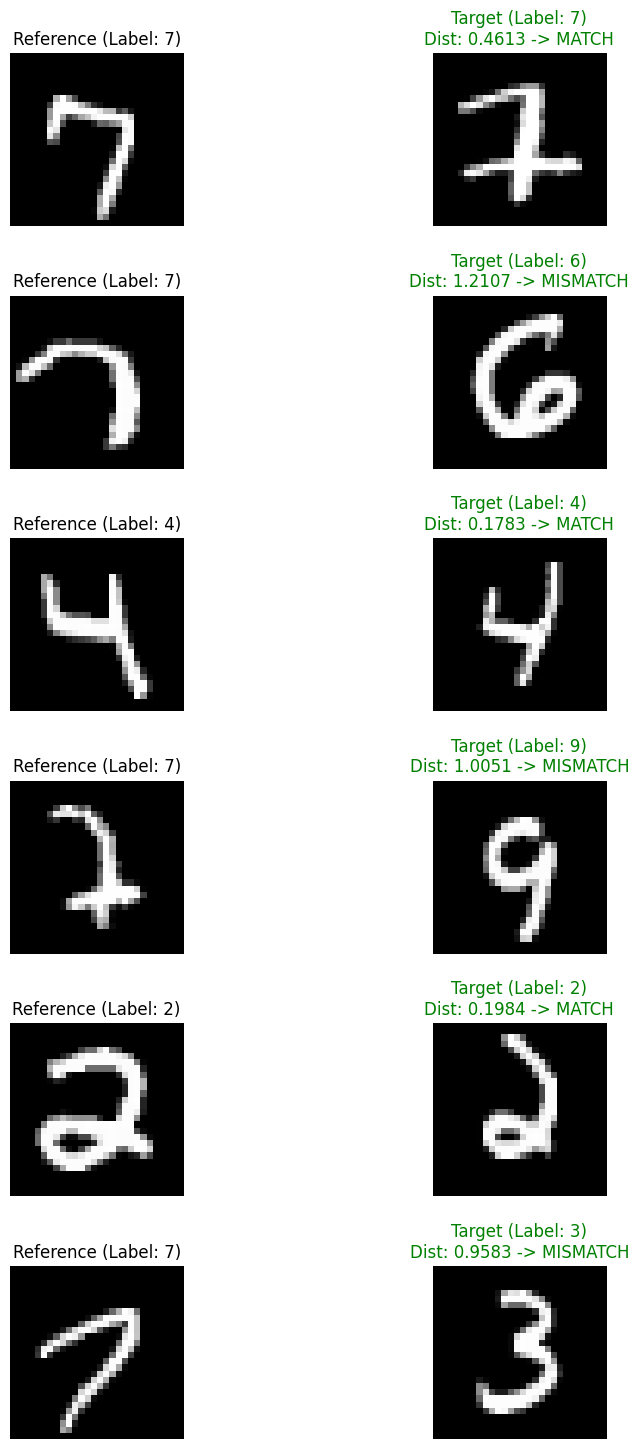

In [4]:
def visualize_detailed_match(num_tests=6):
    model.eval()
    test_ds = datasets.MNIST('./data', train=False, transform=transform)
    
    fig, axes = plt.subplots(num_tests, 2, figsize=(10, 3 * num_tests))
    plt.subplots_adjust(hspace=0.4)

    print("\n--- 🏁 동일/상이 객체 매칭 테스트 시작 ---")
    
    for i in range(num_tests):
        # 짝수 번째는 같은 숫자, 홀수 번째는 다른 숫자로 강제 설정
        is_same = (i % 2 == 0)
        
        idx1 = random.randint(0, len(test_ds)-1)
        img1, label1 = test_ds[idx1]
        
        if is_same:
            # 같은 레이블을 가진 다른 인덱스 찾기
            idx2 = random.randint(0, len(test_ds)-1)
            while test_ds[idx2][1] != label1 or idx1 == idx2:
                idx2 = random.randint(0, len(test_ds)-1)
        else:
            # 다른 레이블을 가진 인덱스 찾기
            idx2 = random.randint(0, len(test_ds)-1)
            while test_ds[idx2][1] == label1:
                idx2 = random.randint(0, len(test_ds)-1)
        
        img2, label2 = test_ds[idx2]
        
        with torch.no_grad():
            distance = model(img1.unsqueeze(0).to(device), img2.unsqueeze(0).to(device)).item()
            
        result = "MATCH" if distance < 0.5 else "MISMATCH"
        color = 'green' if (is_same and result == "MATCH") or (not is_same and result == "MISMATCH") else 'red'
        
        # 이미지 출력
        axes[i, 0].imshow(img1.squeeze().numpy(), cmap='gray')
        axes[i, 0].set_title(f"Reference (Label: {label1})")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(img2.squeeze().numpy(), cmap='gray')
        axes[i, 1].set_title(f"Target (Label: {label2})\nDist: {distance:.4f} -> {result}", color=color)
        axes[i, 1].axis('off')

    plt.show()

# 실행
visualize_detailed_match(6)

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, models
from tqdm import tqdm
import random
import matplotlib.pyplot as plt

# 1. 컬러 이미지용 경량 Siamese CNN (ResNet 기반 추천 또는 커스텀)
# 파라미터를 최소화하기 위해 직접 설계한 3층 CNN입니다.
class ColorSiamese(nn.Module):
    def __init__(self):
        super(ColorSiamese, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), # 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), # 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)), # 전역 평균 풀링으로 파라미터 대폭 절감
            nn.Flatten(),
            nn.Linear(128, 128) 
        )

    def forward(self, img1, img2):
        out1 = self.feature_extractor(img1)
        out2 = self.feature_extractor(img2)
        return torch.norm(out1 - out2, p=2, dim=1)

# 2. 데이터셋 (CIFAR-10 예시 - ImageNet-100도 경로만 바꾸면 동일)
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# CIFAR-10 로드
train_raw = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_raw = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# (이전에 만든 SiameseMNIST 클래스와 동일한 로직의 SiameseDataset 사용)
class SiameseDataset(Dataset):
    def __init__(self, raw_dataset):
        self.ds = raw_dataset
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.randint(0, len(self.ds)-1)
        if same:
            while self.ds[idx2][1] != label1: idx2 = random.randint(0, len(self.ds)-1)
        else:
            while self.ds[idx2][1] == label1: idx2 = random.randint(0, len(self.ds)-1)
        img2, label2 = self.ds[idx2]
        return img1, img2, torch.tensor(1.0 if same else 0.0)

# 3. 학습 설정
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ColorSiamese().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loader = DataLoader(SiameseDataset(train_raw), batch_size=128, shuffle=True)

print("🚀 CIFAR-10/ImageNet 기반 유사도 학습 시작...")
for epoch in range(5):
    model.train()
    loop = tqdm(loader, leave=True)
    for img1, img2, label in loop:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        # Margin을 2.0으로 늘려 변별력을 높임
        loss = label * dist.pow(2) + (1 - label) * F.relu(2.0 - dist).pow(2)
        loss = loss.mean()
        loss.backward()
        optimizer.step()
        loop.set_description(f"Epoch [{epoch+1}/5]")
        loop.set_postfix(loss=loss.item())

100%|██████████| 170M/170M [00:04<00:00, 35.2MB/s] 


🚀 CIFAR-10/ImageNet 기반 유사도 학습 시작...


Epoch [5/5]: 100%|██████████| 391/391 [01:30<00:00,  4.32it/s, loss=0.75] 



--- 🏁 CIFAR-10 실전 객체 매칭 테스트 ---


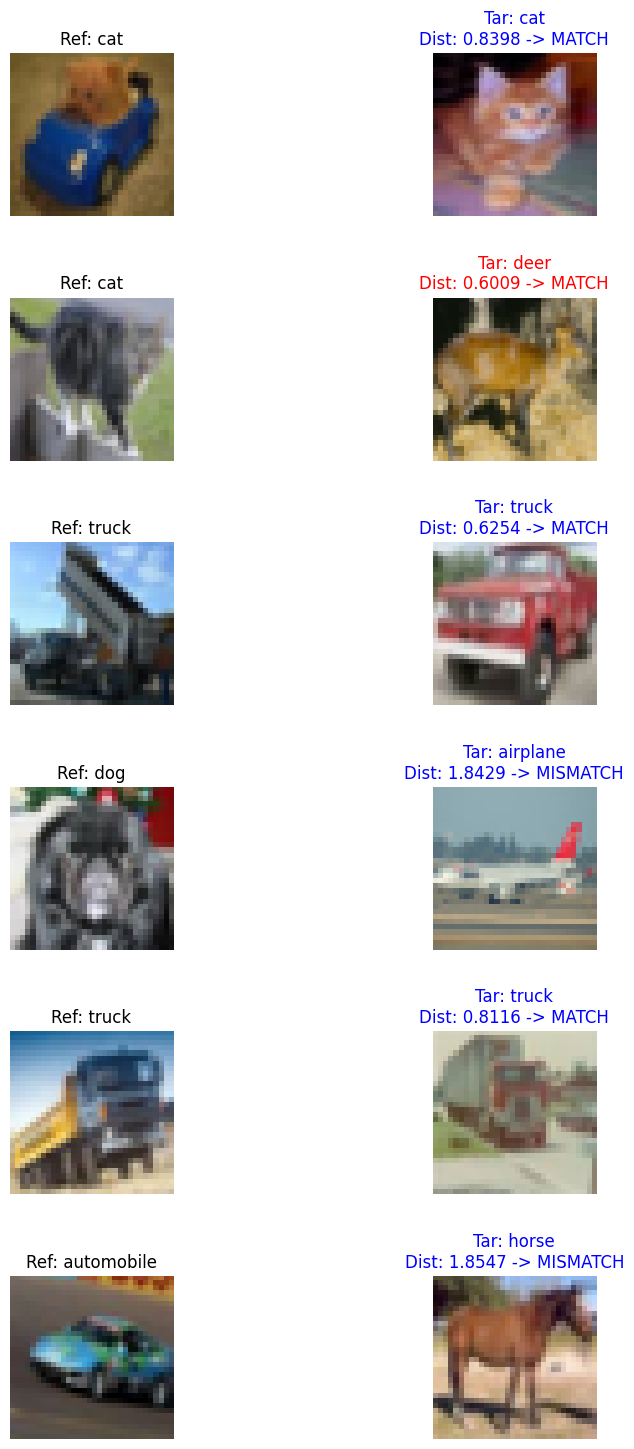

In [6]:
def visualize_color_match(num_tests=6):
    model.eval()
    # CIFAR-10 클래스 명칭
    classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']
    
    fig, axes = plt.subplots(num_tests, 2, figsize=(10, 3 * num_tests))
    plt.subplots_adjust(hspace=0.5)

    print("\n--- 🏁 CIFAR-10 실전 객체 매칭 테스트 ---")
    
    for i in range(num_tests):
        is_same = (i % 2 == 0) # 0, 2, 4행은 같은 종, 1, 3, 5행은 다른 종
        
        idx1 = random.randint(0, len(test_raw)-1)
        img1, label1 = test_raw[idx1]
        
        if is_same:
            idx2 = random.randint(0, len(test_raw)-1)
            while test_raw[idx2][1] != label1 or idx1 == idx2:
                idx2 = random.randint(0, len(test_raw)-1)
        else:
            idx2 = random.randint(0, len(test_raw)-1)
            while test_raw[idx2][1] == label1:
                idx2 = random.randint(0, len(test_raw)-1)
        
        img2, label2 = test_raw[idx2]
        
        # 추론
        with torch.no_grad():
            # [1, 3, 32, 32] 형태로 변환하여 입력
            d = model(img1.unsqueeze(0).to(device), img2.unsqueeze(0).to(device)).item()
            
        # 결과 판정 (컬러는 변별력을 위해 기준을 0.8~1.0 정도로 잡는 게 좋습니다)
        threshold = 1.0 
        result = "MATCH" if d < threshold else "MISMATCH"
        
        # 이미지 역정규화 (시각화용)
        img1_display = img1.permute(1, 2, 0).numpy() * 0.5 + 0.5
        img2_display = img2.permute(1, 2, 0).numpy() * 0.5 + 0.5
        
        # 색상 표시 (성공 시 초록/파랑, 실패 시 빨강)
        correct = (is_same and result=="MATCH") or (not is_same and result=="MISMATCH")
        text_color = 'blue' if correct else 'red'
        
        # 시각화
        axes[i, 0].imshow(img1_display)
        axes[i, 0].set_title(f"Ref: {classes[label1]}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(img2_display)
        axes[i, 1].set_title(f"Tar: {classes[label2]}\nDist: {d:.4f} -> {result}", color=text_color)
        axes[i, 1].axis('off')

    plt.show()

# 실행
visualize_color_match(6)

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm
import random

# 1. MNIST용 극단적 경량 모델 (Single Channel Input)
class MnistSlimSiamese(nn.Module):
    def __init__(self, base_channels=2): # 4 -> 2 -> 1로 줄여보세요
        super(MnistSlimSiamese, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, base_channels, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 14x14
            nn.Conv2d(base_channels, base_channels*2, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 7x7
            nn.Flatten(),
            nn.Linear((base_channels*2) * 7 * 7, 32) 
        )

    def forward(self, x1, x2):
        v1 = self.feature_extractor(x1)
        v2 = self.feature_extractor(x2)
        return torch.norm(v1 - v2, p=2, dim=1)

# 2. 데이터셋 (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_mnist = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_mnist = datasets.MNIST('./data', train=False, download=True, transform=transform)

# (SiameseDataset 클래스는 이전과 동일하게 사용)
class SiameseDataset(Dataset):
    def __init__(self, raw_dataset): self.ds = raw_dataset
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.randint(0, len(self.ds)-1)
        if same:
            while self.ds[idx2][1] != label1: idx2 = random.randint(0, len(self.ds)-1)
        else:
            while self.ds[idx2][1] == label1: idx2 = random.randint(0, len(self.ds)-1)
        return img1, self.ds[idx2][0], torch.tensor(1.0 if same else 0.0)

# 3. 실험 설정
CHANNELS = 2 # <--- MNIST는 2에서도 잘 버틸 겁니다. 1까지 도전해보세요.
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MnistSlimSiamese(base_channels=CHANNELS).to(device)
print(f"📊 MNIST 모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

optimizer = optim.Adam(model.parameters(), lr=0.001)
loader = DataLoader(SiameseDataset(train_mnist), batch_size=128, shuffle=True)

# 4. 학습 (MNIST는 1~2에폭이면 끝납니다)
model.train()
for epoch in range(2):
    for img1, img2, label in tqdm(loader, desc=f"MNIST Epoch {epoch+1}"):
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        loss = (label * dist.pow(2) + (1 - label) * F.relu(1.5 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()

# ... (앞부분 모델 정의 및 데이터 로더는 동일) ...

# 5. 결과 확인 (에러 수정 버전)
model.eval()
s_dist, d_dist = [], []

print(f"🔍 [테스트] 모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

for _ in range(200):
    idx = random.randint(0, len(test_mnist) - 1)
    img1, l1 = test_mnist[idx]
    
    # 같은 클래스 샘플 찾기 (수정됨)
    idx_s = random.randint(0, len(test_mnist) - 1)
    while test_mnist[idx_s][1] != l1:
        idx_s = random.randint(0, len(test_mnist) - 1)
        
    # 다른 클래스 샘플 찾기 (수정됨)
    idx_d = random.randint(0, len(test_mnist) - 1)
    while test_mnist[idx_d][1] == l1:
        idx_d = random.randint(0, len(test_mnist) - 1)
        
    with torch.no_grad():
        d_s = model(img1.unsqueeze(0).to(device), test_mnist[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), test_mnist[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s)
        d_dist.append(d_d)

avg_s, avg_d = sum(s_dist)/200, sum(d_dist)/200
print(f"\n--- 📈 MNIST 결과 (Channels: {CHANNELS}) ---")
print(f"변별력 지수(Gap): {avg_d - avg_s:.4f}")
print(f"상세 거리 -> Same: {avg_s:.4f}, Diff: {avg_d:.4f}")

📊 MNIST 모델 파라미터 수: 6,400


MNIST Epoch 2: 100%|██████████| 469/469 [01:23<00:00,  5.60it/s]


🔍 [테스트] 모델 파라미터 수: 6,400

--- 📈 MNIST 결과 (Channels: 2) ---
변별력 지수(Gap): 0.7716
상세 거리 -> Same: 0.4520, Diff: 1.2236


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm
import random

# 1. MNIST용 극단적 경량 모델 (Single Channel Input)
class MnistSlimSiamese(nn.Module):
    def __init__(self, base_channels=1): # 4 -> 2 -> 1로 줄여보세요
        super(MnistSlimSiamese, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, base_channels, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 14x14
            nn.Conv2d(base_channels, base_channels*2, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 7x7
            nn.Flatten(),
            nn.Linear((base_channels*2) * 7 * 7, 32) 
        )

    def forward(self, x1, x2):
        v1 = self.feature_extractor(x1)
        v2 = self.feature_extractor(x2)
        return torch.norm(v1 - v2, p=2, dim=1)

# 2. 데이터셋 (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_mnist = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_mnist = datasets.MNIST('./data', train=False, download=True, transform=transform)

# (SiameseDataset 클래스는 이전과 동일하게 사용)
class SiameseDataset(Dataset):
    def __init__(self, raw_dataset): self.ds = raw_dataset
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.randint(0, len(self.ds)-1)
        if same:
            while self.ds[idx2][1] != label1: idx2 = random.randint(0, len(self.ds)-1)
        else:
            while self.ds[idx2][1] == label1: idx2 = random.randint(0, len(self.ds)-1)
        return img1, self.ds[idx2][0], torch.tensor(1.0 if same else 0.0)

# 3. 실험 설정
CHANNELS = 1 # <--- MNIST는 2에서도 잘 버틸 겁니다. 1까지 도전해보세요.
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MnistSlimSiamese(base_channels=CHANNELS).to(device)
print(f"📊 MNIST 모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

optimizer = optim.Adam(model.parameters(), lr=0.001)
loader = DataLoader(SiameseDataset(train_mnist), batch_size=128, shuffle=True)

# 4. 학습 (MNIST는 1~2에폭이면 끝납니다)
model.train()
for epoch in range(2):
    for img1, img2, label in tqdm(loader, desc=f"MNIST Epoch {epoch+1}"):
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        loss = (label * dist.pow(2) + (1 - label) * F.relu(1.5 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()

# ... (앞부분 모델 정의 및 데이터 로더는 동일) ...

# 5. 결과 확인 (에러 수정 버전)
model.eval()
s_dist, d_dist = [], []

print(f"🔍 [테스트] 모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

for _ in range(200):
    idx = random.randint(0, len(test_mnist) - 1)
    img1, l1 = test_mnist[idx]
    
    # 같은 클래스 샘플 찾기 (수정됨)
    idx_s = random.randint(0, len(test_mnist) - 1)
    while test_mnist[idx_s][1] != l1:
        idx_s = random.randint(0, len(test_mnist) - 1)
        
    # 다른 클래스 샘플 찾기 (수정됨)
    idx_d = random.randint(0, len(test_mnist) - 1)
    while test_mnist[idx_d][1] == l1:
        idx_d = random.randint(0, len(test_mnist) - 1)
        
    with torch.no_grad():
        d_s = model(img1.unsqueeze(0).to(device), test_mnist[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), test_mnist[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s)
        d_dist.append(d_d)

avg_s, avg_d = sum(s_dist)/200, sum(d_dist)/200
print(f"\n--- 📈 MNIST 결과 (Channels: {CHANNELS}) ---")
print(f"변별력 지수(Gap): {avg_d - avg_s:.4f}")
print(f"상세 거리 -> Same: {avg_s:.4f}, Diff: {avg_d:.4f}")

📊 MNIST 모델 파라미터 수: 3,198


MNIST Epoch 2: 100%|██████████| 469/469 [01:23<00:00,  5.63it/s]


🔍 [테스트] 모델 파라미터 수: 3,198

--- 📈 MNIST 결과 (Channels: 1) ---
변별력 지수(Gap): 0.6591
상세 거리 -> Same: 0.4885, Diff: 1.1476


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm
import random

# 1. CIFAR-10용 초경량 모델 (입력 채널 3으로 변경)
class CifarSlimSiamese(nn.Module):
    def __init__(self, base_channels=1): 
        super(CifarSlimSiamese, self).__init__()
        self.feature_extractor = nn.Sequential(
            # CIFAR-10은 컬러이므로 입력 채널이 3입니다.
            nn.Conv2d(3, base_channels, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 16x16
            nn.Conv2d(base_channels, base_channels*2, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 8x8
            nn.Flatten(),
            # 8*8*base_channels*2 -> base_channels=1일 때 128
            nn.Linear((base_channels*2) * 8 * 8, 32) 
        )

    def forward(self, x1, x2):
        v1 = self.feature_extractor(x1)
        v2 = self.feature_extractor(x2)
        return torch.norm(v1 - v2, p=2, dim=1)

# 2. 데이터셋 (CIFAR-10)
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_cifar = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_cifar = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

class SiameseDataset(Dataset):
    def __init__(self, raw_dataset): self.ds = raw_dataset
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.randint(0, len(self.ds)-1)
        if same:
            while self.ds[idx2][1] != label1: idx2 = random.randint(0, len(self.ds)-1)
        else:
            while self.ds[idx2][1] == label1: idx2 = random.randint(0, len(self.ds)-1)
        return img1, self.ds[idx2][0], torch.tensor(1.0 if same else 0.0)

# 3. 실험 설정
CHANNELS = 1 # <--- MNIST에서 썼던 그 극단적인 설정 그대로!
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CifarSlimSiamese(base_channels=CHANNELS).to(device)
print(f"📊 CIFAR-10 모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

optimizer = optim.Adam(model.parameters(), lr=0.001)
loader = DataLoader(SiameseDataset(train_cifar), batch_size=128, shuffle=True)

# 4. 학습 (CIFAR는 MNIST보다 어려우므로 최소 5에폭 추천하지만, 일단 2에폭으로 비교)
model.train()
for epoch in range(5):
    for img1, img2, label in tqdm(loader, desc=f"CIFAR Epoch {epoch+1}"):
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        loss = (label * dist.pow(2) + (1 - label) * F.relu(1.5 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()

# 5. 결과 확인
model.eval()
s_dist, d_dist = [], []

for _ in range(200):
    idx = random.randint(0, len(test_cifar) - 1)
    img1, l1 = test_cifar[idx]
    
    idx_s = random.randint(0, len(test_cifar) - 1)
    while test_cifar[idx_s][1] != l1:
        idx_s = random.randint(0, len(test_cifar) - 1)
        
    idx_d = random.randint(0, len(test_cifar) - 1)
    while test_cifar[idx_d][1] == l1:
        idx_d = random.randint(0, len(test_cifar) - 1)
        
    with torch.no_grad():
        d_s = model(img1.unsqueeze(0).to(device), test_cifar[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), test_cifar[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s)
        d_dist.append(d_d)

avg_s, avg_d = sum(s_dist)/200, sum(d_dist)/200
print(f"\n--- 📈 CIFAR-10 결과 (Channels: {CHANNELS}) ---")
print(f"변별력 지수(Gap): {avg_d - avg_s:.4f}")
print(f"상세 거리 -> Same: {avg_s:.4f}, Diff: {avg_d:.4f}")

📊 CIFAR-10 모델 파라미터 수: 4,176


CIFAR Epoch 5: 100%|██████████| 391/391 [01:22<00:00,  4.72it/s]



--- 📈 CIFAR-10 결과 (Channels: 1) ---
변별력 지수(Gap): 0.1016
상세 거리 -> Same: 0.6515, Diff: 0.7532


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm
import random

# 1. CIFAR-10용 초경량 모델 (입력 채널 3으로 변경)
class CifarSlimSiamese(nn.Module):
    def __init__(self, base_channels=3): 
        super(CifarSlimSiamese, self).__init__()
        self.feature_extractor = nn.Sequential(
            # CIFAR-10은 컬러이므로 입력 채널이 3입니다.
            nn.Conv2d(3, base_channels, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 16x16
            nn.Conv2d(base_channels, base_channels*2, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 8x8
            nn.Flatten(),
            # 8*8*base_channels*2 -> base_channels=1일 때 128
            nn.Linear((base_channels*2) * 8 * 8, 32) 
        )

    def forward(self, x1, x2):
        v1 = self.feature_extractor(x1)
        v2 = self.feature_extractor(x2)
        return torch.norm(v1 - v2, p=2, dim=1)

# 2. 데이터셋 (CIFAR-10)
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_cifar = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_cifar = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

class SiameseDataset(Dataset):
    def __init__(self, raw_dataset): self.ds = raw_dataset
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.randint(0, len(self.ds)-1)
        if same:
            while self.ds[idx2][1] != label1: idx2 = random.randint(0, len(self.ds)-1)
        else:
            while self.ds[idx2][1] == label1: idx2 = random.randint(0, len(self.ds)-1)
        return img1, self.ds[idx2][0], torch.tensor(1.0 if same else 0.0)

# 3. 실험 설정
CHANNELS = 2 # <--- MNIST에서 썼던 그 극단적인 설정 그대로!
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CifarSlimSiamese(base_channels=CHANNELS).to(device)
print(f"📊 CIFAR-10 모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

optimizer = optim.Adam(model.parameters(), lr=0.001)
loader = DataLoader(SiameseDataset(train_cifar), batch_size=128, shuffle=True)

# 4. 학습 (CIFAR는 MNIST보다 어려우므로 최소 5에폭 추천하지만, 일단 2에폭으로 비교)
model.train()
for epoch in range(2):
    for img1, img2, label in tqdm(loader, desc=f"CIFAR Epoch {epoch+1}"):
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        loss = (label * dist.pow(2) + (1 - label) * F.relu(1.5 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()

# 5. 결과 확인
model.eval()
s_dist, d_dist = [], []

for _ in range(200):
    idx = random.randint(0, len(test_cifar) - 1)
    img1, l1 = test_cifar[idx]
    
    idx_s = random.randint(0, len(test_cifar) - 1)
    while test_cifar[idx_s][1] != l1:
        idx_s = random.randint(0, len(test_cifar) - 1)
        
    idx_d = random.randint(0, len(test_cifar) - 1)
    while test_cifar[idx_d][1] == l1:
        idx_d = random.randint(0, len(test_cifar) - 1)
        
    with torch.no_grad():
        d_s = model(img1.unsqueeze(0).to(device), test_cifar[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), test_cifar[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s)
        d_dist.append(d_d)

avg_s, avg_d = sum(s_dist)/200, sum(d_dist)/200
print(f"\n--- 📈 CIFAR-10 결과 (Channels: {CHANNELS}) ---")
print(f"변별력 지수(Gap): {avg_d - avg_s:.4f}")
print(f"상세 거리 -> Same: {avg_s:.4f}, Diff: {avg_d:.4f}")

📊 CIFAR-10 모델 파라미터 수: 8,356


CIFAR Epoch 2: 100%|██████████| 391/391 [01:23<00:00,  4.69it/s]



--- 📈 CIFAR-10 결과 (Channels: 2) ---
변별력 지수(Gap): 0.1951
상세 거리 -> Same: 0.6408, Diff: 0.8359


In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm
import random

# 1. CIFAR-10용 초경량 모델 (입력 채널 3으로 변경)
class CifarSlimSiamese(nn.Module):
    def __init__(self, base_channels=3): 
        super(CifarSlimSiamese, self).__init__()
        self.feature_extractor = nn.Sequential(
            # CIFAR-10은 컬러이므로 입력 채널이 3입니다.
            nn.Conv2d(3, base_channels, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 16x16
            nn.Conv2d(base_channels, base_channels*2, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 8x8
            nn.Flatten(),
            # 8*8*base_channels*2 -> base_channels=1일 때 128
            nn.Linear((base_channels*2) * 8 * 8, 32) 
        )

    def forward(self, x1, x2):
        v1 = self.feature_extractor(x1)
        v2 = self.feature_extractor(x2)
        return torch.norm(v1 - v2, p=2, dim=1)

# 2. 데이터셋 (CIFAR-10)
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_cifar = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_cifar = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

class SiameseDataset(Dataset):
    def __init__(self, raw_dataset): self.ds = raw_dataset
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.randint(0, len(self.ds)-1)
        if same:
            while self.ds[idx2][1] != label1: idx2 = random.randint(0, len(self.ds)-1)
        else:
            while self.ds[idx2][1] == label1: idx2 = random.randint(0, len(self.ds)-1)
        return img1, self.ds[idx2][0], torch.tensor(1.0 if same else 0.0)

# 3. 실험 설정
CHANNELS = 4 # <--- MNIST에서 썼던 그 극단적인 설정 그대로!
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CifarSlimSiamese(base_channels=CHANNELS).to(device)
print(f"📊 CIFAR-10 모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

optimizer = optim.Adam(model.parameters(), lr=0.001)
loader = DataLoader(SiameseDataset(train_cifar), batch_size=128, shuffle=True)

# 4. 학습 (CIFAR는 MNIST보다 어려우므로 최소 5에폭 추천하지만, 일단 2에폭으로 비교)
model.train()
for epoch in range(5):
    for img1, img2, label in tqdm(loader, desc=f"CIFAR Epoch {epoch+1}"):
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        loss = (label * dist.pow(2) + (1 - label) * F.relu(1.5 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()

# 5. 결과 확인
model.eval()
s_dist, d_dist = [], []

for _ in range(200):
    idx = random.randint(0, len(test_cifar) - 1)
    img1, l1 = test_cifar[idx]
    
    idx_s = random.randint(0, len(test_cifar) - 1)
    while test_cifar[idx_s][1] != l1:
        idx_s = random.randint(0, len(test_cifar) - 1)
        
    idx_d = random.randint(0, len(test_cifar) - 1)
    while test_cifar[idx_d][1] == l1:
        idx_d = random.randint(0, len(test_cifar) - 1)
        
    with torch.no_grad():
        d_s = model(img1.unsqueeze(0).to(device), test_cifar[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), test_cifar[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s)
        d_dist.append(d_d)

avg_s, avg_d = sum(s_dist)/200, sum(d_dist)/200
print(f"\n--- 📈 CIFAR-10 결과 (Channels: {CHANNELS}) ---")
print(f"변별력 지수(Gap): {avg_d - avg_s:.4f}")
print(f"상세 거리 -> Same: {avg_s:.4f}, Diff: {avg_d:.4f}")

📊 CIFAR-10 모델 파라미터 수: 16,824


CIFAR Epoch 5: 100%|██████████| 391/391 [01:21<00:00,  4.79it/s]



--- 📈 CIFAR-10 결과 (Channels: 4) ---
변별력 지수(Gap): 0.2955
상세 거리 -> Same: 0.6762, Diff: 0.9717


In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm
import random

# 1. CIFAR-10용 초경량 모델 (입력 채널 3으로 변경)
class CifarSlimSiamese(nn.Module):
    def __init__(self, base_channels=3): 
        super(CifarSlimSiamese, self).__init__()
        self.feature_extractor = nn.Sequential(
            # CIFAR-10은 컬러이므로 입력 채널이 3입니다.
            nn.Conv2d(3, base_channels, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 16x16
            nn.Conv2d(base_channels, base_channels*2, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 8x8
            nn.Flatten(),
            # 8*8*base_channels*2 -> base_channels=1일 때 128
            nn.Linear((base_channels*2) * 8 * 8, 32) 
        )

    def forward(self, x1, x2):
        v1 = self.feature_extractor(x1)
        v2 = self.feature_extractor(x2)
        return torch.norm(v1 - v2, p=2, dim=1)

# 2. 데이터셋 (CIFAR-10)
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_cifar = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_cifar = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

class SiameseDataset(Dataset):
    def __init__(self, raw_dataset): self.ds = raw_dataset
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.randint(0, len(self.ds)-1)
        if same:
            while self.ds[idx2][1] != label1: idx2 = random.randint(0, len(self.ds)-1)
        else:
            while self.ds[idx2][1] == label1: idx2 = random.randint(0, len(self.ds)-1)
        return img1, self.ds[idx2][0], torch.tensor(1.0 if same else 0.0)

# 3. 실험 설정
CHANNELS = 5 # <--- MNIST에서 썼던 그 극단적인 설정 그대로!
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CifarSlimSiamese(base_channels=CHANNELS).to(device)
print(f"📊 CIFAR-10 모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

optimizer = optim.Adam(model.parameters(), lr=0.001)
loader = DataLoader(SiameseDataset(train_cifar), batch_size=128, shuffle=True)

# 4. 학습 (CIFAR는 MNIST보다 어려우므로 최소 5에폭 추천하지만, 일단 2에폭으로 비교)
model.train()
for epoch in range(5):
    for img1, img2, label in tqdm(loader, desc=f"CIFAR Epoch {epoch+1}"):
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        loss = (label * dist.pow(2) + (1 - label) * F.relu(1.5 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()

# 5. 결과 확인
model.eval()
s_dist, d_dist = [], []

for _ in range(200):
    idx = random.randint(0, len(test_cifar) - 1)
    img1, l1 = test_cifar[idx]
    
    idx_s = random.randint(0, len(test_cifar) - 1)
    while test_cifar[idx_s][1] != l1:
        idx_s = random.randint(0, len(test_cifar) - 1)
        
    idx_d = random.randint(0, len(test_cifar) - 1)
    while test_cifar[idx_d][1] == l1:
        idx_d = random.randint(0, len(test_cifar) - 1)
        
    with torch.no_grad():
        d_s = model(img1.unsqueeze(0).to(device), test_cifar[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), test_cifar[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s)
        d_dist.append(d_d)

avg_s, avg_d = sum(s_dist)/200, sum(d_dist)/200
print(f"\n--- 📈 CIFAR-10 결과 (Channels: {CHANNELS}) ---")
print(f"변별력 지수(Gap): {avg_d - avg_s:.4f}")
print(f"상세 거리 -> Same: {avg_s:.4f}, Diff: {avg_d:.4f}")

📊 CIFAR-10 모델 파라미터 수: 21,112


CIFAR Epoch 5: 100%|██████████| 391/391 [01:22<00:00,  4.71it/s]



--- 📈 CIFAR-10 결과 (Channels: 5) ---
변별력 지수(Gap): 0.2839
상세 거리 -> Same: 0.6242, Diff: 0.9081


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm
import random

# 1. CIFAR-10용 초경량 모델 (입력 채널 3으로 변경)
class CifarSlimSiamese(nn.Module):
    def __init__(self, base_channels=3): 
        super(CifarSlimSiamese, self).__init__()
        self.feature_extractor = nn.Sequential(
            # CIFAR-10은 컬러이므로 입력 채널이 3입니다.
            nn.Conv2d(3, base_channels, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 16x16
            nn.Conv2d(base_channels, base_channels*2, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 8x8
            nn.Flatten(),
            # 8*8*base_channels*2 -> base_channels=1일 때 128
            nn.Linear((base_channels*2) * 8 * 8, 32) 
        )

    def forward(self, x1, x2):
        v1 = self.feature_extractor(x1)
        v2 = self.feature_extractor(x2)
        return torch.norm(v1 - v2, p=2, dim=1)

# 2. 데이터셋 (CIFAR-10)
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_cifar = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_cifar = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

class SiameseDataset(Dataset):
    def __init__(self, raw_dataset): self.ds = raw_dataset
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.randint(0, len(self.ds)-1)
        if same:
            while self.ds[idx2][1] != label1: idx2 = random.randint(0, len(self.ds)-1)
        else:
            while self.ds[idx2][1] == label1: idx2 = random.randint(0, len(self.ds)-1)
        return img1, self.ds[idx2][0], torch.tensor(1.0 if same else 0.0)

# 3. 실험 설정
CHANNELS = 6 # <--- MNIST에서 썼던 그 극단적인 설정 그대로!
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CifarSlimSiamese(base_channels=CHANNELS).to(device)
print(f"📊 CIFAR-10 모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

optimizer = optim.Adam(model.parameters(), lr=0.001)
loader = DataLoader(SiameseDataset(train_cifar), batch_size=128, shuffle=True)

# 4. 학습 (CIFAR는 MNIST보다 어려우므로 최소 5에폭 추천하지만, 일단 2에폭으로 비교)
model.train()
for epoch in range(5):
    for img1, img2, label in tqdm(loader, desc=f"CIFAR Epoch {epoch+1}"):
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        loss = (label * dist.pow(2) + (1 - label) * F.relu(1.5 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()

# 5. 결과 확인
model.eval()
s_dist, d_dist = [], []

for _ in range(200):
    idx = random.randint(0, len(test_cifar) - 1)
    img1, l1 = test_cifar[idx]
    
    idx_s = random.randint(0, len(test_cifar) - 1)
    while test_cifar[idx_s][1] != l1:
        idx_s = random.randint(0, len(test_cifar) - 1)
        
    idx_d = random.randint(0, len(test_cifar) - 1)
    while test_cifar[idx_d][1] == l1:
        idx_d = random.randint(0, len(test_cifar) - 1)
        
    with torch.no_grad():
        d_s = model(img1.unsqueeze(0).to(device), test_cifar[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), test_cifar[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s)
        d_dist.append(d_d)

avg_s, avg_d = sum(s_dist)/200, sum(d_dist)/200
print(f"\n--- 📈 CIFAR-10 결과 (Channels: {CHANNELS}) ---")
print(f"변별력 지수(Gap): {avg_d - avg_s:.4f}")
print(f"상세 거리 -> Same: {avg_s:.4f}, Diff: {avg_d:.4f}")

📊 CIFAR-10 모델 파라미터 수: 25,436


CIFAR Epoch 5: 100%|██████████| 391/391 [01:22<00:00,  4.73it/s]



--- 📈 CIFAR-10 결과 (Channels: 6) ---
변별력 지수(Gap): 0.2791
상세 거리 -> Same: 0.6814, Diff: 0.9605


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm
import random

# 1. CIFAR-10용 초경량 모델 (입력 채널 3으로 변경)
class CifarSlimSiamese(nn.Module):
    def __init__(self, base_channels=3): 
        super(CifarSlimSiamese, self).__init__()
        self.feature_extractor = nn.Sequential(
            # CIFAR-10은 컬러이므로 입력 채널이 3입니다.
            nn.Conv2d(3, base_channels, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 16x16
            nn.Conv2d(base_channels, base_channels*2, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 8x8
            nn.Flatten(),
            # 8*8*base_channels*2 -> base_channels=1일 때 128
            nn.Linear((base_channels*2) * 8 * 8, 32) 
        )

    def forward(self, x1, x2):
        v1 = self.feature_extractor(x1)
        v2 = self.feature_extractor(x2)
        return torch.norm(v1 - v2, p=2, dim=1)

# 2. 데이터셋 (CIFAR-10)
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_cifar = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_cifar = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

class SiameseDataset(Dataset):
    def __init__(self, raw_dataset): self.ds = raw_dataset
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.randint(0, len(self.ds)-1)
        if same:
            while self.ds[idx2][1] != label1: idx2 = random.randint(0, len(self.ds)-1)
        else:
            while self.ds[idx2][1] == label1: idx2 = random.randint(0, len(self.ds)-1)
        return img1, self.ds[idx2][0], torch.tensor(1.0 if same else 0.0)

# 3. 실험 설정
CHANNELS = 8 # <--- MNIST에서 썼던 그 극단적인 설정 그대로!
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CifarSlimSiamese(base_channels=CHANNELS).to(device)
print(f"📊 CIFAR-10 모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

optimizer = optim.Adam(model.parameters(), lr=0.001)
loader = DataLoader(SiameseDataset(train_cifar), batch_size=128, shuffle=True)

# 4. 학습 (CIFAR는 MNIST보다 어려우므로 최소 5에폭 추천하지만, 일단 2에폭으로 비교)
model.train()
for epoch in range(5):
    for img1, img2, label in tqdm(loader, desc=f"CIFAR Epoch {epoch+1}"):
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        loss = (label * dist.pow(2) + (1 - label) * F.relu(1.5 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()

# 5. 결과 확인
model.eval()
s_dist, d_dist = [], []

for _ in range(200):
    idx = random.randint(0, len(test_cifar) - 1)
    img1, l1 = test_cifar[idx]
    
    idx_s = random.randint(0, len(test_cifar) - 1)
    while test_cifar[idx_s][1] != l1:
        idx_s = random.randint(0, len(test_cifar) - 1)
        
    idx_d = random.randint(0, len(test_cifar) - 1)
    while test_cifar[idx_d][1] == l1:
        idx_d = random.randint(0, len(test_cifar) - 1)
        
    with torch.no_grad():
        d_s = model(img1.unsqueeze(0).to(device), test_cifar[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), test_cifar[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s)
        d_dist.append(d_d)

avg_s, avg_d = sum(s_dist)/200, sum(d_dist)/200
print(f"\n--- 📈 CIFAR-10 결과 (Channels: {CHANNELS}) ---")
print(f"변별력 지수(Gap): {avg_d - avg_s:.4f}")
print(f"상세 거리 -> Same: {avg_s:.4f}, Diff: {avg_d:.4f}")

📊 CIFAR-10 모델 파라미터 수: 34,192


CIFAR Epoch 5: 100%|██████████| 391/391 [01:23<00:00,  4.70it/s]



--- 📈 CIFAR-10 결과 (Channels: 8) ---
변별력 지수(Gap): 0.3477
상세 거리 -> Same: 0.5948, Diff: 0.9425


In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm
import random

# 1. CIFAR-10용 초경량 모델 (입력 채널 3으로 변경)
class CifarSlimSiamese(nn.Module):
    def __init__(self, base_channels=3): 
        super(CifarSlimSiamese, self).__init__()
        self.feature_extractor = nn.Sequential(
            # CIFAR-10은 컬러이므로 입력 채널이 3입니다.
            nn.Conv2d(3, base_channels, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 16x16
            nn.Conv2d(base_channels, base_channels*2, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 8x8
            nn.Flatten(),
            # 8*8*base_channels*2 -> base_channels=1일 때 128
            nn.Linear((base_channels*2) * 8 * 8, 32) 
        )

    def forward(self, x1, x2):
        v1 = self.feature_extractor(x1)
        v2 = self.feature_extractor(x2)
        return torch.norm(v1 - v2, p=2, dim=1)

# 2. 데이터셋 (CIFAR-10)
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_cifar = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_cifar = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

class SiameseDataset(Dataset):
    def __init__(self, raw_dataset): self.ds = raw_dataset
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.randint(0, len(self.ds)-1)
        if same:
            while self.ds[idx2][1] != label1: idx2 = random.randint(0, len(self.ds)-1)
        else:
            while self.ds[idx2][1] == label1: idx2 = random.randint(0, len(self.ds)-1)
        return img1, self.ds[idx2][0], torch.tensor(1.0 if same else 0.0)

# 3. 실험 설정
CHANNELS = 16 # <--- MNIST에서 썼던 그 극단적인 설정 그대로!
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CifarSlimSiamese(base_channels=CHANNELS).to(device)
print(f"📊 CIFAR-10 모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

optimizer = optim.Adam(model.parameters(), lr=0.001)
loader = DataLoader(SiameseDataset(train_cifar), batch_size=128, shuffle=True)

# 4. 학습 (CIFAR는 MNIST보다 어려우므로 최소 5에폭 추천하지만, 일단 2에폭으로 비교)
model.train()
for epoch in range(5):
    for img1, img2, label in tqdm(loader, desc=f"CIFAR Epoch {epoch+1}"):
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        loss = (label * dist.pow(2) + (1 - label) * F.relu(1.5 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()

# 5. 결과 확인
model.eval()
s_dist, d_dist = [], []

for _ in range(200):
    idx = random.randint(0, len(test_cifar) - 1)
    img1, l1 = test_cifar[idx]
    
    idx_s = random.randint(0, len(test_cifar) - 1)
    while test_cifar[idx_s][1] != l1:
        idx_s = random.randint(0, len(test_cifar) - 1)
        
    idx_d = random.randint(0, len(test_cifar) - 1)
    while test_cifar[idx_d][1] == l1:
        idx_d = random.randint(0, len(test_cifar) - 1)
        
    with torch.no_grad():
        d_s = model(img1.unsqueeze(0).to(device), test_cifar[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), test_cifar[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s)
        d_dist.append(d_d)

avg_s, avg_d = sum(s_dist)/200, sum(d_dist)/200
print(f"\n--- 📈 CIFAR-10 결과 (Channels: {CHANNELS}) ---")
print(f"변별력 지수(Gap): {avg_d - avg_s:.4f}")
print(f"상세 거리 -> Same: {avg_s:.4f}, Diff: {avg_d:.4f}")

📊 CIFAR-10 모델 파라미터 수: 70,656


CIFAR Epoch 5: 100%|██████████| 391/391 [01:23<00:00,  4.69it/s]



--- 📈 CIFAR-10 결과 (Channels: 16) ---
변별력 지수(Gap): 0.3730
상세 거리 -> Same: 0.6292, Diff: 1.0022


In [1]:
# 실제 데이터가 들어있는 폴더 경로를 입력하세요.
# 예: '/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train'
TRAIN_DATA_PATH = '/kaggle/input/datasets/ifigotin/imagenetmini-1000/imagenet-mini/train'

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm
import random
import os

# 1. 경로 설정 (사용자 확인 경로)
TRAIN_DATA_PATH = '/kaggle/input/datasets/ifigotin/imagenetmini-1000/imagenet-mini/train'

# 2. 모델 정의 (154,688 파라미터 - 지능의 해상도 강화 버전)
class ImageNetExpertSiamese(nn.Module):
    def __init__(self, base_channels=16):
        super(ImageNetExpertSiamese, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, base_channels, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 32x32
            nn.Conv2d(base_channels, base_channels*2, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 16x16
            nn.Conv2d(base_channels*2, base_channels*4, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 8x8
            nn.Flatten(),
            nn.Linear((base_channels*4) * 8 * 8, 32) 
        )

    def forward(self, x1, x2):
        v1 = self.feature_extractor(x1)
        v2 = self.feature_extractor(x2)
        return torch.norm(v1 - v2, p=2, dim=1)

# 3. 고속 데이터셋 클래스 (인덱싱 최적화)
class FastSiameseDataset(Dataset):
    def __init__(self, raw_dataset):
        self.ds = raw_dataset
        print("⚡ 데이터 인덱싱 중... (클래스별 위치 파악)")
        self.label_to_indices = {}
        for idx in range(len(raw_dataset)):
            _, label = raw_dataset[idx]
            if label not in self.label_to_indices:
                self.label_to_indices[label] = []
            self.label_to_indices[label].append(idx)
        self.labels = list(self.label_to_indices.keys())
        print(f"✅ 인덱싱 완료! (총 {len(self.labels)}개 클래스)")

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        
        if same:
            # 같은 클래스에서 무작위 선택 (매우 빠름)
            idx2 = random.choice(self.label_to_indices[label1])
        else:
            # 다른 클래스에서 무작위 선택
            diff_label = random.choice(self.labels)
            while diff_label == label1:
                diff_label = random.choice(self.labels)
            idx2 = random.choice(self.label_to_indices[diff_label])
            
        img2, _ = self.ds[idx2]
        return img1, img2, torch.tensor(1.0 if same else 0.0)

# 4. 데이터 로드 및 전처리
img_size = 64
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

if os.path.exists(TRAIN_DATA_PATH):
    full_dataset = datasets.ImageFolder(root=TRAIN_DATA_PATH, transform=transform)
    # 실험 속도를 위해 2만 장만 샘플링 (경향 파악용)
    train_size = min(20000, len(full_dataset))
    train_subset, _ = torch.utils.data.random_split(full_dataset, [train_size, len(full_dataset)-train_size])
    siamese_train = FastSiameseDataset(train_subset)
else:
    raise FileNotFoundError("❌ 경로를 다시 확인해주세요!")

# DataLoader 최적화 (num_workers가 속도의 핵심)
loader = DataLoader(siamese_train, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)

# 5. 학습 루프
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ImageNetExpertSiamese(base_channels=16).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

model.train()
print(f"🚀 학습 시작 (장치: {device} / 파라미터: {sum(p.numel() for p in model.parameters()):,})")

for epoch in range(5):
    pbar = tqdm(loader, desc="ImageNet 학습")
    for img1, img2, label in pbar:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        # Contrastive Loss (불량 검사의 핵심 원리)
        loss = (label * dist.pow(2) + (1 - label) * F.relu(1.5 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

# 6. 불량 검사 변별력(Gap) 측정
model.eval()
s_dist, d_dist = [], []
print("\n🔍 거리 기반 변별력(Gap) 측정 중...")
for _ in range(300):
    idx = random.randint(0, len(full_dataset) - 1)
    img1, l1 = full_dataset[idx]
    
    # 정상 시나리오 (같은 클래스 간 거리)
    idx_s = random.choice(siamese_train.label_to_indices.get(l1, [idx]))
    
    # 불량 시나리오 (다른 클래스 간 거리)
    diff_l = random.choice(siamese_train.labels)
    while diff_l == l1: diff_l = random.choice(siamese_train.labels)
    idx_d = random.choice(siamese_train.label_to_indices[diff_l])
    
    with torch.no_grad():
        d_s = model(img1.unsqueeze(0).to(device), full_dataset[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), full_dataset[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s); d_dist.append(d_d)

avg_s, avg_d = sum(s_dist)/300, sum(d_dist)/300
print(f"\n--- 📈 ImageNet-Mini 최종 실험 결과 ---")
print(f"변별력 지수(Gap): {avg_d - avg_s:.4f}")
print(f"정상간 평균 거리 (Same): {avg_s:.4f}")
print(f"불량간 평균 거리 (Diff): {avg_d:.4f}")

⚡ 데이터 인덱싱 중... (클래스별 위치 파악)
✅ 인덱싱 완료! (총 1000개 클래스)
🚀 학습 시작 (장치: cuda / 파라미터: 154,688)


ImageNet 학습: 100%|██████████| 157/157 [01:05<00:00,  2.39it/s, loss=0.4656]



🔍 거리 기반 변별력(Gap) 측정 중...

--- 📈 ImageNet-Mini 최종 실험 결과 ---
변별력 지수(Gap): 0.0069
정상간 평균 거리 (Same): 0.7087
불량간 평균 거리 (Diff): 0.7156


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm
import random
import os

# 1. 경로 설정 (사용자 확인 경로)
TRAIN_DATA_PATH = '/kaggle/input/datasets/ifigotin/imagenetmini-1000/imagenet-mini/train'

# 2. 모델 정의 (614,560 파라미터 - 지능의 그릇 확장)
class ImageNetHeavySiamese(nn.Module):
    def __init__(self, base_channels=32): # 16에서 32로 증설
        super(ImageNetHeavySiamese, self).__init__()
        self.feature_extractor = nn.Sequential(
            # 입력: 3 x 64 x 64
            nn.Conv2d(3, base_channels, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 32x32
            nn.Conv2d(base_channels, base_channels*2, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 16x16
            nn.Conv2d(base_channels*2, base_channels*4, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 8x8
            nn.Flatten(),
            # 8 * 8 * (32 * 4) = 8192 -> 32차원 임베딩
            nn.Linear((base_channels*4) * 8 * 8, 32) 
        )

    def forward(self, x1, x2):
        v1 = self.feature_extractor(x1)
        v2 = self.feature_extractor(x2)
        return torch.norm(v1 - v2, p=2, dim=1)

# 모델 생성 시
model = ImageNetHeavySiamese(base_channels=32).to(device)
print(f"📊 증설된 모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

# 3. 고속 데이터셋 클래스 (인덱싱 최적화)
class FastSiameseDataset(Dataset):
    def __init__(self, raw_dataset):
        self.ds = raw_dataset
        print("⚡ 데이터 인덱싱 중... (클래스별 위치 파악)")
        self.label_to_indices = {}
        for idx in range(len(raw_dataset)):
            _, label = raw_dataset[idx]
            if label not in self.label_to_indices:
                self.label_to_indices[label] = []
            self.label_to_indices[label].append(idx)
        self.labels = list(self.label_to_indices.keys())
        print(f"✅ 인덱싱 완료! (총 {len(self.labels)}개 클래스)")

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        
        if same:
            # 같은 클래스에서 무작위 선택 (매우 빠름)
            idx2 = random.choice(self.label_to_indices[label1])
        else:
            # 다른 클래스에서 무작위 선택
            diff_label = random.choice(self.labels)
            while diff_label == label1:
                diff_label = random.choice(self.labels)
            idx2 = random.choice(self.label_to_indices[diff_label])
            
        img2, _ = self.ds[idx2]
        return img1, img2, torch.tensor(1.0 if same else 0.0)

# 4. 데이터 로드 및 전처리
img_size = 64
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

if os.path.exists(TRAIN_DATA_PATH):
    full_dataset = datasets.ImageFolder(root=TRAIN_DATA_PATH, transform=transform)
    # 실험 속도를 위해 2만 장만 샘플링 (경향 파악용)
    train_size = min(20000, len(full_dataset))
    train_subset, _ = torch.utils.data.random_split(full_dataset, [train_size, len(full_dataset)-train_size])
    siamese_train = FastSiameseDataset(train_subset)
else:
    raise FileNotFoundError("❌ 경로를 다시 확인해주세요!")

# DataLoader 최적화 (num_workers가 속도의 핵심)
loader = DataLoader(siamese_train, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)

# 5. 학습 루프
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ImageNetExpertSiamese(base_channels=16).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

model.train()
print(f"🚀 학습 시작 (장치: {device} / 파라미터: {sum(p.numel() for p in model.parameters()):,})")

for epoch in range(5):
    pbar = tqdm(loader, desc="ImageNet 학습")
    for img1, img2, label in pbar:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        # Contrastive Loss (불량 검사의 핵심 원리)
        loss = (label * dist.pow(2) + (1 - label) * F.relu(1.5 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

# 6. 불량 검사 변별력(Gap) 측정
model.eval()
s_dist, d_dist = [], []
print("\n🔍 거리 기반 변별력(Gap) 측정 중...")
for _ in range(300):
    idx = random.randint(0, len(full_dataset) - 1)
    img1, l1 = full_dataset[idx]
    
    # 정상 시나리오 (같은 클래스 간 거리)
    idx_s = random.choice(siamese_train.label_to_indices.get(l1, [idx]))
    
    # 불량 시나리오 (다른 클래스 간 거리)
    diff_l = random.choice(siamese_train.labels)
    while diff_l == l1: diff_l = random.choice(siamese_train.labels)
    idx_d = random.choice(siamese_train.label_to_indices[diff_l])
    
    with torch.no_grad():
        d_s = model(img1.unsqueeze(0).to(device), full_dataset[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), full_dataset[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s); d_dist.append(d_d)

avg_s, avg_d = sum(s_dist)/300, sum(d_dist)/300
print(f"\n--- 📈 ImageNet-Mini 최종 실험 결과 ---")
print(f"변별력 지수(Gap): {avg_d - avg_s:.4f}")
print(f"정상간 평균 거리 (Same): {avg_s:.4f}")
print(f"불량간 평균 거리 (Diff): {avg_d:.4f}")

📊 증설된 모델 파라미터 수: 355,424
⚡ 데이터 인덱싱 중... (클래스별 위치 파악)
✅ 인덱싱 완료! (총 1000개 클래스)
🚀 학습 시작 (장치: cuda / 파라미터: 154,688)


ImageNet 학습: 100%|██████████| 157/157 [01:04<00:00,  2.44it/s, loss=0.5213]



🔍 거리 기반 변별력(Gap) 측정 중...

--- 📈 ImageNet-Mini 최종 실험 결과 ---
변별력 지수(Gap): 0.0087
정상간 평균 거리 (Same): 0.7546
불량간 평균 거리 (Diff): 0.7633


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import random

# --- [1. 가변 깊이 시아미즈 모델] ---
class VariableDeepSiamese(nn.Module):
    def __init__(self, num_layers, base_channels=32):
        super(VariableDeepSiamese, self).__init__()
        layers = []
        in_channels = 3
        curr_channels = base_channels
        
        # 포문으로 레이어를 num_layers만큼 쌓음
        for i in range(num_layers):
            layers.append(nn.Conv2d(in_channels, curr_channels, kernel_size=3, padding=1))
            layers.append(nn.ReLU())
            # 2층마다 풀링하여 해상도 조절 (너무 작아지지 않게)
            if (i + 1) % 2 == 0 and i < num_layers - 1:
                layers.append(nn.MaxPool2d(2))
            in_channels = curr_channels
            # 채널은 일정 수준까지만 확장
            if (i + 1) % 2 == 0:
                curr_channels = min(curr_channels * 2, 128)
        
        self.feature_extractor = nn.Sequential(*layers, nn.AdaptiveAvgPool2d((4, 4)), nn.Flatten())
        
        # 마지막 Linear 층 (지능의 최종 출력)
        # AdaptiveAvgPool 덕분에 레이어가 아무리 많아도 Linear 입력 크기가 고정됨
        self.fc = nn.Linear(curr_channels * 4 * 4, 128)

    def forward(self, x1, x2):
        v1 = F.normalize(self.fc(self.feature_extractor(x1)), p=2, dim=1)
        v2 = F.normalize(self.fc(self.feature_extractor(x2)), p=2, dim=1)
        return torch.norm(v1 - v2, p=2, dim=1)

# --- [2. 실험 루프 자동화] ---

depth_list = [3, 6, 9, 12] # 실험하고 싶은 레이어 깊이들
results = []

for L in depth_list:
    model = VariableDeepSiamese(num_layers=L).to(device)
    params = sum(p.numel() for p in model.parameters())
    print(f"\n🔥 레이어 {L}층 실험 시작 | 파라미터: {params:,}")
    
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # 학습 (빠른 확인을 위해 2에폭만 수행)
    for epoch in range(2):
        model.train()
        pbar = tqdm(loader, desc=f"L{L} Depth Training")
        for img1, img2, label in pbar:
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            optimizer.zero_grad()
            dist = model(img1, img2)
            loss = (label * dist.pow(2) + (1 - label) * F.relu(1.5 - dist).pow(2)).mean()
            loss.backward()
            optimizer.step()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    # Gap 측정
    model.eval()
    s_dist, d_dist = [], []
    with torch.no_grad():
        for _ in range(300):
            idx = random.randint(0, len(full_dataset)-1)
            img1, l1 = full_dataset[idx]
            idx_s = random.choice(siamese_train.label_to_indices.get(l1, [idx]))
            diff_l = random.choice(siamese_train.labels)
            idx_d = random.choice(siamese_train.label_to_indices[diff_l])
            
            d_s = model(img1.unsqueeze(0).to(device), full_dataset[idx_s][0].unsqueeze(0).to(device)).item()
            d_d = model(img1.unsqueeze(0).to(device), full_dataset[idx_d][0].unsqueeze(0).to(device)).item()
            s_dist.append(d_s); d_dist.append(d_d)
            
    gap = (sum(d_dist)/300) - (sum(s_dist)/300)
    results.append({"layers": L, "params": params, "gap": gap})

# --- [3. 결과 비교] ---
print("\n" + "="*50)
print("📊 레이어 깊이(L)에 따른 지능 발현 리포트")
print("="*50)
for r in results:
    print(f"[{r['layers']} Layers] Params: {r['params']:,} | Gap: {r['gap']:.4f}")


🔥 레이어 3층 실험 시작 | 파라미터: 159,840


L3 Depth Training: 100%|██████████| 157/157 [01:44<00:00,  1.51it/s, loss=0.5796]



🔥 레이어 6층 실험 시작 | 파라미터: 549,280


L6 Depth Training: 100%|██████████| 157/157 [01:40<00:00,  1.56it/s, loss=0.5006]



🔥 레이어 9층 실험 시작 | 파라미터: 992,032


L9 Depth Training: 100%|██████████| 157/157 [02:15<00:00,  1.15it/s, loss=0.5542]



🔥 레이어 12층 실험 시작 | 파라미터: 1,434,784


L12 Depth Training: 100%|██████████| 157/157 [01:38<00:00,  1.59it/s, loss=0.5736]



📊 레이어 깊이(L)에 따른 지능 발현 리포트
[3 Layers] Params: 159,840 | Gap: -0.0014
[6 Layers] Params: 549,280 | Gap: 0.0161
[9 Layers] Params: 992,032 | Gap: 0.0083
[12 Layers] Params: 1,434,784 | Gap: -0.0019


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm
import random
import os

# --- [1. 환경 및 경로 설정] ---
device = "cuda" if torch.cuda.is_available() else "cpu"
# Kaggle용 ImageNet-Mini 경로 (사용자 확인 경로)
TRAIN_DATA_PATH = '/kaggle/input/datasets/ifigotin/imagenetmini-1000/imagenet-mini/train'

# --- [2. 지능 복구형 6층 모델 정의] ---
# 지능 발현이 가장 좋았던 6층(Depth=6) 구조를 고정하고 임베딩 차원만 변경합니다.
class RecoverySiamese(nn.Module):
    def __init__(self, embed_dim):
        super(RecoverySiamese, self).__init__()
        base_channels = 32
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, base_channels, 3, padding=1), nn.ReLU(),
            nn.Conv2d(base_channels, base_channels, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 32x32
            nn.Conv2d(base_channels, base_channels*2, 3, padding=1), nn.ReLU(),
            nn.Conv2d(base_channels*2, base_channels*2, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), # 16x16
            nn.Conv2d(base_channels*2, base_channels*4, 3, padding=1), nn.ReLU(),
            nn.Conv2d(base_channels*4, base_channels*4, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten()
        )
        # 최종 출력 차원 (지능의 시력/해상도)
        self.fc = nn.Linear(base_channels*4 * 4 * 4, embed_dim)

    def forward(self, x1, x2):
        # 특징 추출 후 L2 정규화로 변별력 극대화
        v1 = F.normalize(self.fc(self.feature_extractor(x1)), p=2, dim=1)
        v2 = F.normalize(self.fc(self.feature_extractor(x2)), p=2, dim=1)
        return torch.norm(v1 - v2, p=2, dim=1)

# --- [3. 고속 데이터 로딩 설정] ---
class FastSiameseDataset(Dataset):
    def __init__(self, raw_dataset):
        self.ds = raw_dataset
        self.label_to_indices = {}
        for idx in range(len(raw_dataset)):
            _, label = raw_dataset[idx]
            if label not in self.label_to_indices: self.label_to_indices[label] = []
            self.label_to_indices[label].append(idx)
        self.labels = list(self.label_to_indices.keys())

    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.choice(self.label_to_indices[label1]) if same else random.randint(0, len(self.ds)-1)
        img2, _ = self.ds[idx2]
        return img1, img2, torch.tensor(1.0 if same else 0.0)

# 전처리 및 데이터 로더 준비
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

if os.path.exists(TRAIN_DATA_PATH):
    full_dataset = datasets.ImageFolder(root=TRAIN_DATA_PATH, transform=transform)
    # 실험 속도를 위해 20,000장 샘플링
    train_size = min(20000, len(full_dataset))
    train_subset, _ = torch.utils.data.random_split(full_dataset, [train_size, len(full_dataset)-train_size])
    siamese_train = FastSiameseDataset(train_subset)
    loader = DataLoader(siamese_train, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
else:
    raise FileNotFoundError(f"❌ 경로를 찾을 수 없습니다: {TRAIN_DATA_PATH}")

# --- [4. 임베딩 차원별 자동 실험 루프] ---
embed_list = [32, 128, 512] 
recovery_results = []

print(f"🚀 실험 시작 (장치: {device})")

for E in embed_list:
    model = RecoverySiamese(embed_dim=E).to(device)
    params = sum(p.numel() for p in model.parameters())
    print(f"\n✨ 실험: Embedding Dimension = {E} | 파라미터: {params:,}")
    
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # 지능 복구 확인을 위해 각 2에폭 학습
    for epoch in range(2):
        model.train()
        pbar = tqdm(loader, desc=f"E{E} Training Epoch {epoch+1}")
        for img1, img2, label in pbar:
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            optimizer.zero_grad()
            dist = model(img1, img2)
            # Contrastive Loss
            loss = (label * dist.pow(2) + (1 - label) * F.relu(1.5 - dist).pow(2)).mean()
            loss.backward()
            optimizer.step()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    # Gap 측정 (변별 지수)
    model.eval()
    s_dist, d_dist = [], []
    with torch.no_grad():
        for _ in range(500):
            idx = random.randint(0, len(full_dataset)-1)
            img1, l1 = full_dataset[idx]
            # Same 클래스 거리
            idx_s = random.choice(siamese_train.label_to_indices.get(l1, [idx]))
            # Diff 클래스 거리
            diff_l = random.choice(siamese_train.labels)
            while diff_l == l1: diff_l = random.choice(siamese_train.labels)
            idx_d = random.choice(siamese_train.label_to_indices[diff_l])
            
            d_s = model(img1.unsqueeze(0).to(device), full_dataset[idx_s][0].unsqueeze(0).to(device)).item()
            d_d = model(img1.unsqueeze(0).to(device), full_dataset[idx_d][0].unsqueeze(0).to(device)).item()
            s_dist.append(d_s); d_dist.append(d_d)
            
    gap = (sum(d_dist)/500) - (sum(s_dist)/500)
    recovery_results.append({"dim": E, "gap": gap})

# --- [5. 최종 결과 리포트] ---
print("\n" + "="*50)
print("📊 지능 복구 실험 결과 (L6 모델 고정)")
print("="*50)
for r in recovery_results:
    status = "복구 중..." if r['gap'] > 0.01 else "붕괴 상태"
    print(f"[Embedding {r['dim']:>3} Dim] 변별력(Gap): {r['gap']:.4f} -> {status}")
print("="*50)

🚀 실험 시작 (장치: cuda)

✨ 실험: Embedding Dimension = 32 | 파라미터: 352,576


E32 Training Epoch 2: 100%|██████████| 157/157 [01:47<00:00,  1.46it/s, loss=0.5469]



✨ 실험: Embedding Dimension = 128 | 파라미터: 549,280


E128 Training Epoch 2: 100%|██████████| 157/157 [01:45<00:00,  1.49it/s, loss=0.6112]



✨ 실험: Embedding Dimension = 512 | 파라미터: 1,336,096


E512 Training Epoch 2: 100%|██████████| 157/157 [01:48<00:00,  1.45it/s, loss=0.5423]



📊 지능 복구 실험 결과 (L6 모델 고정)
[Embedding  32 Dim] 변별력(Gap): -0.0078 -> 붕괴 상태
[Embedding 128 Dim] 변별력(Gap): 0.0006 -> 붕괴 상태
[Embedding 512 Dim] 변별력(Gap): -0.0064 -> 붕괴 상태


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm
import random
import os

# --- [1. 환경 설정] ---
device = "cuda" if torch.cuda.is_available() else "cpu"
TRAIN_DATA_PATH = '/kaggle/input/datasets/ifigotin/imagenetmini-1000/imagenet-mini/train'

# --- [2. 지능 각성형 모델 정의 (BatchNorm 도입)] ---
class NormalizedSiamese(nn.Module):
    def __init__(self, embed_dim=256):
        super(NormalizedSiamese, self).__init__()
        
        # 반복되는 컨볼루션 블록을 함수화 (Conv + BatchNorm + ReLU)
        def conv_block(in_f, out_f):
            return nn.Sequential(
                nn.Conv2d(in_f, out_f, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_f), # 내부 데이터 정렬 (지능 복구의 핵심)
                nn.ReLU()
            )
        
        self.feature_extractor = nn.Sequential(
            conv_block(3, 32), conv_block(32, 32), nn.MaxPool2d(2), # 32x32
            conv_block(32, 64), conv_block(64, 64), nn.MaxPool2d(2), # 16x16
            conv_block(64, 128), conv_block(128, 128), # 16x16 유지 (정보 보존)
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten()
        )
        
        # 마지막 출력층 (임베딩 차원을 256으로 고정)
        self.fc = nn.Linear(128 * 4 * 4, embed_dim)

    def forward(self, x1, x2):
        # 특징 추출 후 L2 정규화
        v1 = F.normalize(self.fc(self.feature_extractor(x1)), p=2, dim=1)
        v2 = F.normalize(self.fc(self.feature_extractor(x2)), p=2, dim=1)
        return torch.norm(v1 - v2, p=2, dim=1)

# --- [3. 데이터 로딩 (Fast Mode)] ---
class FastSiameseDataset(Dataset):
    def __init__(self, raw_dataset):
        self.ds = raw_dataset
        self.label_to_indices = {}
        for idx in range(len(raw_dataset)):
            _, label = raw_dataset[idx]
            if label not in self.label_to_indices: self.label_to_indices[label] = []
            self.label_to_indices[label].append(idx)
        self.labels = list(self.label_to_indices.keys())

    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.choice(self.label_to_indices[label1]) if same else random.randint(0, len(self.ds)-1)
        img2, _ = self.ds[idx2]
        return img1, img2, torch.tensor(1.0 if same else 0.0)

# 전처리 설정
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 데이터셋 로드
full_dataset = datasets.ImageFolder(root=TRAIN_DATA_PATH, transform=transform)
train_size = min(20000, len(full_dataset))
train_subset, _ = torch.utils.data.random_split(full_dataset, [train_size, len(full_dataset)-train_size])
siamese_train = FastSiameseDataset(train_subset)
loader = DataLoader(siamese_train, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

# --- [4. 학습 및 지능 각성 루프] ---
model = NormalizedSiamese().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# OneCycleLR: 학습률을 역동적으로 조절하여 지역 최적점을 탈출함
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, 
                                          steps_per_epoch=len(loader), epochs=3)

print(f"🔥 지능 각성 실험 시작 (파라미터: {sum(p.numel() for p in model.parameters()):,})")

for epoch in range(3):
    model.train()
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for img1, img2, label in pbar:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        
        optimizer.zero_grad()
        dist = model(img1, img2)
        
        # Contrastive Loss (거리 기반 학습)
        loss = (label * dist.pow(2) + (1 - label) * F.relu(1.5 - dist).pow(2)).mean()
        loss.backward()
        
        optimizer.step()
        scheduler.step() # 학습률 업데이트
        
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{scheduler.get_last_lr()[0]:.5f}")

# --- [5. 최종 변별력(Gap) 측정] ---
model.eval()
s_dist, d_dist = [], []
with torch.no_grad():
    for _ in range(500):
        idx = random.randint(0, len(full_dataset)-1)
        img1, l1 = full_dataset[idx]
        idx_s = random.choice(siamese_train.label_to_indices.get(l1, [idx]))
        diff_l = random.choice(siamese_train.labels)
        idx_d = random.choice(siamese_train.label_to_indices[diff_l])
        
        d_s = model(img1.unsqueeze(0).to(device), full_dataset[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), full_dataset[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s); d_dist.append(d_d)

avg_s, avg_d = sum(s_dist)/500, sum(d_dist)/500
print("\n" + "="*50)
print(f"📊 최종 지능 각성 결과")
print(f"변별력 지수(Gap): {avg_d - avg_s:.4f}")
print(f"Same(정상) 거리: {avg_s:.4f} | Diff(오답) 거리: {avg_d:.4f}")
print("="*50)

🔥 지능 각성 실험 시작 (파라미터: 812,448)


Epoch 3: 100%|██████████| 157/157 [01:42<00:00,  1.53it/s, loss=0.5048, lr=0.00000]



📊 최종 지능 각성 결과
변별력 지수(Gap): -0.0014
Same(정상) 거리: 0.8066 | Diff(오답) 거리: 0.8053


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm
import random
import os

# --- [1. 환경 설정] ---
device = "cuda" if torch.cuda.is_available() else "cpu"
TRAIN_DATA_PATH = '/kaggle/input/datasets/ifigotin/imagenetmini-1000/imagenet-mini/train'

# --- [2. Residual Block 정의 (정보의 지름길)] ---
class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_c)
        )
        
        # 입력과 출력의 차원이 다를 때 맞춰주는 처리 (Identity Mapping)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_c)
            )

    def forward(self, x):
        # 핵심: conv(x) 결과에 원본 x(shortcut)를 더함
        out = self.conv(x) + self.shortcut(x)
        return F.relu(out)

# --- [3. ResNet 기반 시아미즈 모델] ---
class SmartResSiamese(nn.Module):
    def __init__(self, embed_dim=256):
        super(SmartResSiamese, self).__init__()
        # 점진적으로 채널을 늘리며 특징 추출
        self.layer1 = ResidualBlock(3, 32, stride=2)   # 64 -> 32
        self.layer2 = ResidualBlock(32, 64, stride=2)  # 32 -> 16
        self.layer3 = ResidualBlock(64, 128, stride=2) # 16 -> 8
        self.layer4 = ResidualBlock(128, 256, stride=2)# 8 -> 4
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, embed_dim)

    def forward_one(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x).view(x.size(0), -1)
        x = self.fc(x)
        return F.normalize(x, p=2, dim=1) # L2 정규화로 구 표면에 배치

    def forward(self, x1, x2):
        v1 = self.forward_one(x1)
        v2 = self.forward_one(x2)
        return torch.norm(v1 - v2, p=2, dim=1)

# --- [4. 데이터셋 및 로더 (기존 설정 유지)] ---
class FastSiameseDataset(Dataset):
    def __init__(self, raw_dataset):
        self.ds = raw_dataset
        self.label_to_indices = {l: [] for _, l in raw_dataset}
        for idx, (_, l) in enumerate(raw_dataset):
            self.label_to_indices[l].append(idx)
        self.labels = list(self.label_to_indices.keys())

    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.choice(self.label_to_indices[label1]) if same else random.randint(0, len(self.ds)-1)
        img2, _ = self.ds[idx2]
        return img1, img2, torch.tensor(1.0 if same else 0.0)

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=TRAIN_DATA_PATH, transform=transform)
train_subset, _ = torch.utils.data.random_split(full_dataset, [20000, len(full_dataset)-20000])
siamese_train = FastSiameseDataset(train_subset)
loader = DataLoader(siamese_train, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

# --- [5. 지능 복구 학습 실행] ---
model = SmartResSiamese(embed_dim=256).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
# CosineAnnealing으로 부드럽게 수렴 유도
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=3)

print(f"🚀 ResNet 지능 돌파 실험 시작 (파라미터: {sum(p.numel() for p in model.parameters()):,})")

for epoch in range(3):
    model.train()
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for img1, img2, label in pbar:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        
        optimizer.zero_grad()
        dist = model(img1, img2)
        # Margin을 2.0으로 높여서 더 강력하게 밀어냄
        loss = (label * dist.pow(2) + (1 - label) * F.relu(2.0 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        pbar.set_postfix(loss=f"{loss.item():.4f}")

# --- [6. 최종 변별력 측정] ---
model.eval()
s_dist, d_dist = [], []
with torch.no_grad():
    for _ in range(500):
        idx = random.randint(0, len(full_dataset)-1)
        img1, l1 = full_dataset[idx]
        idx_s = random.choice(siamese_train.label_to_indices.get(l1, [idx]))
        diff_l = random.choice(siamese_train.labels); idx_d = random.choice(siamese_train.label_to_indices[diff_l])
        
        d_s = model(img1.unsqueeze(0).to(device), full_dataset[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), full_dataset[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s); d_dist.append(d_d)

print("\n" + "="*50)
print(f"📊 ResNet 기반 최종 결과")
print(f"변별력 지수(Gap): {sum(d_dist)/500 - sum(s_dist)/500:.4f}")
print("="*50)

🚀 ResNet 지능 돌파 실험 시작 (파라미터: 1,283,072)


Epoch 3: 100%|██████████| 157/157 [01:36<00:00,  1.63it/s, loss=1.1728]



📊 ResNet 기반 최종 결과
변별력 지수(Gap): 0.0081


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import torch.optim as optim
from tqdm import tqdm
import random
import os

# --- [1. 환경 설정] ---
device = "cuda" if torch.cuda.is_available() else "cpu"
TRAIN_DATA_PATH = '/kaggle/input/datasets/ifigotin/imagenetmini-1000/imagenet-mini/train'

# --- [2. Heavy Residual Block (채널 확장형)] ---
class HeavyBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super(HeavyBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_c)
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_c)
            )

    def forward(self, x):
        return F.relu(self.conv(x) + self.shortcut(x))

# --- [3. Heavy ResNet Siamese (체급 5배 뻥튀기)] ---
class HeavyResSiamese(nn.Module):
    def __init__(self, embed_dim=512): # 임베딩도 512로 확장
        super(HeavyResSiamese, self).__init__()
        # 초기 채널을 64로 시작 (기존 32에서 확장)
        self.layer1 = HeavyBlock(3, 64, stride=2)   # 32x32
        self.layer2 = HeavyBlock(64, 128, stride=2)  # 16x16
        self.layer3 = HeavyBlock(128, 256, stride=2) # 8x8
        self.layer4 = HeavyBlock(256, 512, stride=2) # 4x4
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        # 512차원의 특징을 512차원 임베딩으로 연결
        self.fc = nn.Linear(512, embed_dim)

    def forward_one(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x).view(x.size(0), -1)
        x = self.fc(x)
        return F.normalize(x, p=2, dim=1)

    def forward(self, x1, x2):
        v1 = self.forward_one(x1)
        v2 = self.forward_one(x2)
        return torch.norm(v1 - v2, p=2, dim=1)

# --- [4. 데이터셋 및 고속 로더] ---
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class FastSiameseDataset(Dataset):
    def __init__(self, raw_dataset):
        self.ds = raw_dataset
        self.label_to_indices = {}
        for idx in range(len(raw_dataset)):
            _, l = raw_dataset[idx]
            if l not in self.label_to_indices: self.label_to_indices[l] = []
            self.label_to_indices[l].append(idx)
        self.labels = list(self.label_to_indices.keys())

    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.choice(self.label_to_indices[label1]) if same else random.randint(0, len(self.ds)-1)
        img2, _ = self.ds[idx2]
        return img1, img2, torch.tensor(1.0 if same else 0.0)

full_dataset = datasets.ImageFolder(root=TRAIN_DATA_PATH, transform=transform)
train_subset, _ = torch.utils.data.random_split(full_dataset, [25000, len(full_dataset)-25000])
siamese_train = FastSiameseDataset(train_subset)
loader = DataLoader(siamese_train, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)

# --- [5. 학습 실행] ---
model = HeavyResSiamese().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4) # AdamW로 안정성 강화
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.005, steps_per_epoch=len(loader), epochs=3)

print(f"🚀 Heavy-ResNet 돌파 실험 시작 (파라미터: {sum(p.numel() for p in model.parameters()):,})")

for epoch in range(3):
    model.train()
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for img1, img2, label in pbar:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        # 강력한 Margin 2.0 적용
        loss = (label * dist.pow(2) + (1 - label) * F.relu(2.0 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()
        scheduler.step()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

# --- [6. 최종 변별력 측정] ---
model.eval()
s_dist, d_dist = [], []
with torch.no_grad():
    for _ in range(500):
        idx = random.randint(0, len(full_dataset)-1)
        img1, l1 = full_dataset[idx]
        idx_s = random.choice(siamese_train.label_to_indices.get(l1, [idx]))
        diff_l = random.choice(siamese_train.labels); idx_d = random.choice(siamese_train.label_to_indices[diff_l])
        d_s = model(img1.unsqueeze(0).to(device), full_dataset[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), full_dataset[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s); d_dist.append(d_d)

print("\n" + "="*50)
print(f"📊 Heavy-ResNet 최종 결과")
print(f"변별력 지수(Gap): {sum(d_dist)/500 - sum(s_dist)/500:.4f}")
print("="*50)

🚀 Heavy-ResNet 돌파 실험 시작 (파라미터: 5,124,096)


Epoch 3: 100%|██████████| 196/196 [01:28<00:00,  2.22it/s, loss=0.9532]



📊 Heavy-ResNet 최종 결과
변별력 지수(Gap): -0.0129


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
from tqdm import tqdm
import random

# --- [1. 모델 정의: 공식 ResNet-18 (Pre-trained = False)] ---
class OfficialResNetSiamese(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        # 깡통 ResNet-18 로드 (지능의 설계도만 빌림)
        self.base_model = models.resnet18(weights=None) 
        # 마지막 FC층을 제거하고 우리만의 임베딩 층 추가
        in_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Linear(in_features, embed_dim)

    def forward_one(self, x):
        x = self.base_model(x)
        return F.normalize(x, p=2, dim=1)

    def forward(self, x1, x2):
        return torch.norm(self.forward_one(x1) - self.forward_one(x2), p=2, dim=1)

# --- [2. 손실 함수: Triplet Margin Loss (더 강력한 지능 주입)] ---
# 이번엔 3개를 비교하는 대신, 기존 로직에 'Hard Margin'을 더 강하게 줍니다.
def hard_margin_loss(dist, label, margin=2.5):
    loss_same = label * dist.pow(2)
    # 오답을 더 멀리, 더 강하게 밀어냄 (Margin 2.5)
    loss_diff = (1 - label) * F.relu(margin - dist).pow(2)
    return (loss_same + loss_diff * 2.0).mean()

# --- [3. 학습 설정 (ResNet-18 체급에 맞춰 최적화)] ---
model = OfficialResNetSiamese().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-2)
# 에폭을 5회로 늘려 지능이 깨어날 시간을 줍니다.
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

print(f"🔥 ResNet-18 정면 돌파 시작 (파라미터: {sum(p.numel() for p in model.parameters()):,})")

for epoch in range(5):
    model.train()
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for img1, img2, label in pbar:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        loss = hard_margin_loss(dist, label)
        loss.backward()
        optimizer.step()
        scheduler.step()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

# --- [4. 데이터셋 및 고속 로더] ---
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class FastSiameseDataset(Dataset):
    def __init__(self, raw_dataset):
        self.ds = raw_dataset
        self.label_to_indices = {}
        for idx in range(len(raw_dataset)):
            _, l = raw_dataset[idx]
            if l not in self.label_to_indices: self.label_to_indices[l] = []
            self.label_to_indices[l].append(idx)
        self.labels = list(self.label_to_indices.keys())

    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.choice(self.label_to_indices[label1]) if same else random.randint(0, len(self.ds)-1)
        img2, _ = self.ds[idx2]
        return img1, img2, torch.tensor(1.0 if same else 0.0)

full_dataset = datasets.ImageFolder(root=TRAIN_DATA_PATH, transform=transform)
train_subset, _ = torch.utils.data.random_split(full_dataset, [25000, len(full_dataset)-25000])
siamese_train = FastSiameseDataset(train_subset)
loader = DataLoader(siamese_train, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)

# --- [5. 학습 실행] ---
model = HeavyResSiamese().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4) # AdamW로 안정성 강화
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.005, steps_per_epoch=len(loader), epochs=3)

print(f"🚀 Heavy-ResNet 돌파 실험 시작 (파라미터: {sum(p.numel() for p in model.parameters()):,})")

for epoch in range(3):
    model.train()
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for img1, img2, label in pbar:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        # 강력한 Margin 2.0 적용
        loss = (label * dist.pow(2) + (1 - label) * F.relu(2.0 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()
        scheduler.step()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

# --- [6. 최종 변별력 측정] ---
model.eval()
s_dist, d_dist = [], []
with torch.no_grad():
    for _ in range(500):
        idx = random.randint(0, len(full_dataset)-1)
        img1, l1 = full_dataset[idx]
        idx_s = random.choice(siamese_train.label_to_indices.get(l1, [idx]))
        diff_l = random.choice(siamese_train.labels); idx_d = random.choice(siamese_train.label_to_indices[diff_l])
        d_s = model(img1.unsqueeze(0).to(device), full_dataset[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), full_dataset[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s); d_dist.append(d_d)

print("\n" + "="*50)
print(f"📊 Heavy-ResNet 최종 결과")
print(f"변별력 지수(Gap): {sum(d_dist)/500 - sum(s_dist)/500:.4f}")
print("="*50)

🔥 ResNet-18 정면 돌파 시작 (파라미터: 11,439,168)


Epoch 5: 100%|██████████| 196/196 [01:27<00:00,  2.24it/s, loss=2.3998]


🚀 Heavy-ResNet 돌파 실험 시작 (파라미터: 5,124,096)


Epoch 3: 100%|██████████| 196/196 [01:27<00:00,  2.25it/s, loss=1.0412]



📊 Heavy-ResNet 최종 결과
변별력 지수(Gap): -0.0280


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Dataset, Subset
import torch.optim as optim
from tqdm import tqdm
import random

# --- [1. 데이터셋 다이어트 (1000 -> 10 클래스)] ---
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

raw_dataset = datasets.ImageFolder(root=TRAIN_DATA_PATH, transform=transform)

# 상위 10개 클래스의 인덱스만 추출
target_classes = list(range(10)) 
indices = [i for i, (_, label) in enumerate(raw_dataset) if label in target_classes]
diet_dataset = Subset(raw_dataset, indices)

print(f"✅ 데이터 다이어트 완료: 1,000개 -> 10개 클래스 (총 {len(diet_dataset)}장)")

# --- [2. 시아미즈 로더 (10개 클래스 전용)] ---
class DietSiameseDataset(Dataset):
    def __init__(self, subset):
        self.ds = subset
        self.label_to_indices = {}
        for idx in range(len(subset)):
            _, l = subset[idx]
            if l not in self.label_to_indices: self.label_to_indices[l] = []
            self.label_to_indices[l].append(idx)
        self.labels = list(self.label_to_indices.keys())

    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.choice(self.label_to_indices[label1]) if same else random.randint(0, len(self.ds)-1)
        img2, _ = self.ds[idx2]
        return img1, img2, torch.tensor(1.0 if same else 0.0)

siamese_diet = DietSiameseDataset(diet_dataset)
loader = DataLoader(siamese_diet, batch_size=64, shuffle=True)

# --- [3. 모델 및 학습 (ResNet-18 그대로 유지)] ---
model = OfficialResNetSiamese(embed_dim=256).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"🚀 [ImageNet-10] 정밀 지능 테스트 시작...")

for epoch in range(3):
    model.train()
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for img1, img2, label in pbar:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        # Margin 2.0 적용
        loss = (label * dist.pow(2) + (1 - label) * F.relu(2.0 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

# --- [4. 변별력 측정] ---
model.eval()
s_dist, d_dist = [], []
with torch.no_grad():
    for _ in range(200):
        idx = random.randint(0, len(diet_dataset)-1)
        img1, l1 = diet_dataset[idx]
        idx_s = random.choice(siamese_diet.label_to_indices[l1])
        diff_l = random.choice([l for l in siamese_diet.labels if l != l1])
        idx_d = random.choice(siamese_diet.label_to_indices[diff_l])
        
        d_s = model(img1.unsqueeze(0).to(device), diet_dataset[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), diet_dataset[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s); d_dist.append(d_d)

print("\n" + "="*50)
print(f"📊 [ImageNet-10] 최종 결과")
print(f"변별력 지수(Gap): {sum(d_dist)/200 - sum(s_dist)/200:.4f}")
print("="*50)

✅ 데이터 다이어트 완료: 1,000개 -> 10개 클래스 (총 316장)
🚀 [ImageNet-10] 정밀 지능 테스트 시작...


Epoch 3: 100%|██████████| 5/5 [00:03<00:00,  1.62it/s, loss=0.8785]



📊 [ImageNet-10] 최종 결과
변별력 지수(Gap): 0.2196


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Dataset, Subset
import torch.optim as optim
from tqdm import tqdm
import random

# --- [1. 데이터셋 다이어트 (1000 -> 10 클래스)] ---
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

raw_dataset = datasets.ImageFolder(root=TRAIN_DATA_PATH, transform=transform)

# 상위 10개 클래스의 인덱스만 추출
target_classes = list(range(10)) 
indices = [i for i, (_, label) in enumerate(raw_dataset) if label in target_classes]
diet_dataset = Subset(raw_dataset, indices)

print(f"✅ 데이터 다이어트 완료: 1,000개 -> 10개 클래스 (총 {len(diet_dataset)}장)")

# --- [2. 시아미즈 로더 (10개 클래스 전용)] ---
class DietSiameseDataset(Dataset):
    def __init__(self, subset):
        self.ds = subset
        self.label_to_indices = {}
        for idx in range(len(subset)):
            _, l = subset[idx]
            if l not in self.label_to_indices: self.label_to_indices[l] = []
            self.label_to_indices[l].append(idx)
        self.labels = list(self.label_to_indices.keys())

    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.choice(self.label_to_indices[label1]) if same else random.randint(0, len(self.ds)-1)
        img2, _ = self.ds[idx2]
        return img1, img2, torch.tensor(1.0 if same else 0.0)

siamese_diet = DietSiameseDataset(diet_dataset)
loader = DataLoader(siamese_diet, batch_size=64, shuffle=True)

# --- [3. 모델 및 학습 (ResNet-18 그대로 유지)] ---
model = OfficialResNetSiamese(embed_dim=256).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"🚀 [ImageNet-10] 정밀 지능 테스트 시작...")

for epoch in range(10):
    model.train()
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for img1, img2, label in pbar:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        # Margin 2.0 적용
        loss = (label * dist.pow(2) + (1 - label) * F.relu(2.0 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

# --- [4. 변별력 측정] ---
model.eval()
s_dist, d_dist = [], []
with torch.no_grad():
    for _ in range(200):
        idx = random.randint(0, len(diet_dataset)-1)
        img1, l1 = diet_dataset[idx]
        idx_s = random.choice(siamese_diet.label_to_indices[l1])
        diff_l = random.choice([l for l in siamese_diet.labels if l != l1])
        idx_d = random.choice(siamese_diet.label_to_indices[diff_l])
        
        d_s = model(img1.unsqueeze(0).to(device), diet_dataset[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), diet_dataset[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s); d_dist.append(d_d)

print("\n" + "="*50)
print(f"📊 [ImageNet-10] 최종 결과")
print(f"변별력 지수(Gap): {sum(d_dist)/200 - sum(s_dist)/200:.4f}")
print("="*50)

✅ 데이터 다이어트 완료: 1,000개 -> 10개 클래스 (총 316장)
🚀 [ImageNet-10] 정밀 지능 테스트 시작...


Epoch 10: 100%|██████████| 5/5 [00:03<00:00,  1.61it/s, loss=0.8452]



📊 [ImageNet-10] 최종 결과
변별력 지수(Gap): 0.4404


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Dataset, Subset
import torch.optim as optim
from tqdm import tqdm
import random

# --- [1. 데이터셋 다이어트 (1000 -> 10 클래스)] ---
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

raw_dataset = datasets.ImageFolder(root=TRAIN_DATA_PATH, transform=transform)

# 상위 10개 클래스의 인덱스만 추출
target_classes = list(range(20)) 
indices = [i for i, (_, label) in enumerate(raw_dataset) if label in target_classes]
diet_dataset = Subset(raw_dataset, indices)

print(f"✅ 데이터 다이어트 완료: 1,000개 -> 10개 클래스 (총 {len(diet_dataset)}장)")

# --- [2. 시아미즈 로더 (10개 클래스 전용)] ---
class DietSiameseDataset(Dataset):
    def __init__(self, subset):
        self.ds = subset
        self.label_to_indices = {}
        for idx in range(len(subset)):
            _, l = subset[idx]
            if l not in self.label_to_indices: self.label_to_indices[l] = []
            self.label_to_indices[l].append(idx)
        self.labels = list(self.label_to_indices.keys())

    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.choice(self.label_to_indices[label1]) if same else random.randint(0, len(self.ds)-1)
        img2, _ = self.ds[idx2]
        return img1, img2, torch.tensor(1.0 if same else 0.0)

siamese_diet = DietSiameseDataset(diet_dataset)
loader = DataLoader(siamese_diet, batch_size=64, shuffle=True)

# --- [3. 모델 및 학습 (ResNet-18 그대로 유지)] ---
model = OfficialResNetSiamese(embed_dim=256).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"🚀 [ImageNet-10] 정밀 지능 테스트 시작...")

for epoch in range(10):
    model.train()
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for img1, img2, label in pbar:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        # Margin 2.0 적용
        loss = (label * dist.pow(2) + (1 - label) * F.relu(2.0 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

# --- [4. 변별력 측정] ---
model.eval()
s_dist, d_dist = [], []
with torch.no_grad():
    for _ in range(200):
        idx = random.randint(0, len(diet_dataset)-1)
        img1, l1 = diet_dataset[idx]
        idx_s = random.choice(siamese_diet.label_to_indices[l1])
        diff_l = random.choice([l for l in siamese_diet.labels if l != l1])
        idx_d = random.choice(siamese_diet.label_to_indices[diff_l])
        
        d_s = model(img1.unsqueeze(0).to(device), diet_dataset[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), diet_dataset[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s); d_dist.append(d_d)

print("\n" + "="*50)
print(f"📊 [ImageNet-10] 최종 결과")
print(f"변별력 지수(Gap): {sum(d_dist)/200 - sum(s_dist)/200:.4f}")
print("="*50)

✅ 데이터 다이어트 완료: 1,000개 -> 10개 클래스 (총 638장)
🚀 [ImageNet-10] 정밀 지능 테스트 시작...


Epoch 10: 100%|██████████| 10/10 [00:06<00:00,  1.55it/s, loss=0.9073]



📊 [ImageNet-10] 최종 결과
변별력 지수(Gap): 0.3410


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Dataset, Subset
import torch.optim as optim
from tqdm import tqdm
import random

# --- [1. 데이터셋 다이어트 (1000 -> 10 클래스)] ---
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

raw_dataset = datasets.ImageFolder(root=TRAIN_DATA_PATH, transform=transform)

# 상위 10개 클래스의 인덱스만 추출
target_classes = list(range(50)) 
indices = [i for i, (_, label) in enumerate(raw_dataset) if label in target_classes]
diet_dataset = Subset(raw_dataset, indices)

print(f"✅ 데이터 다이어트 완료: 1,000개 -> 10개 클래스 (총 {len(diet_dataset)}장)")

# --- [2. 시아미즈 로더 (10개 클래스 전용)] ---
class DietSiameseDataset(Dataset):
    def __init__(self, subset):
        self.ds = subset
        self.label_to_indices = {}
        for idx in range(len(subset)):
            _, l = subset[idx]
            if l not in self.label_to_indices: self.label_to_indices[l] = []
            self.label_to_indices[l].append(idx)
        self.labels = list(self.label_to_indices.keys())

    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.choice(self.label_to_indices[label1]) if same else random.randint(0, len(self.ds)-1)
        img2, _ = self.ds[idx2]
        return img1, img2, torch.tensor(1.0 if same else 0.0)

siamese_diet = DietSiameseDataset(diet_dataset)
loader = DataLoader(siamese_diet, batch_size=64, shuffle=True)

# --- [3. 모델 및 학습 (ResNet-18 그대로 유지)] ---
model = OfficialResNetSiamese(embed_dim=256).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"🚀 [ImageNet-10] 정밀 지능 테스트 시작...")

for epoch in range(10):
    model.train()
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for img1, img2, label in pbar:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        # Margin 2.0 적용
        loss = (label * dist.pow(2) + (1 - label) * F.relu(2.0 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

# --- [4. 변별력 측정] ---
model.eval()
s_dist, d_dist = [], []
with torch.no_grad():
    for _ in range(200):
        idx = random.randint(0, len(diet_dataset)-1)
        img1, l1 = diet_dataset[idx]
        idx_s = random.choice(siamese_diet.label_to_indices[l1])
        diff_l = random.choice([l for l in siamese_diet.labels if l != l1])
        idx_d = random.choice(siamese_diet.label_to_indices[diff_l])
        
        d_s = model(img1.unsqueeze(0).to(device), diet_dataset[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), diet_dataset[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s); d_dist.append(d_d)

print("\n" + "="*50)
print(f"📊 [ImageNet-10] 최종 결과")
print(f"변별력 지수(Gap): {sum(d_dist)/200 - sum(s_dist)/200:.4f}")
print("="*50)

✅ 데이터 다이어트 완료: 1,000개 -> 10개 클래스 (총 1561장)
🚀 [ImageNet-10] 정밀 지능 테스트 시작...


Epoch 10: 100%|██████████| 25/25 [00:15<00:00,  1.58it/s, loss=0.9927]



📊 [ImageNet-10] 최종 결과
변별력 지수(Gap): 0.1313


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Dataset, Subset
import torch.optim as optim
from tqdm import tqdm
import random

# --- [1. 데이터셋 다이어트 (1000 -> 10 클래스)] ---
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

raw_dataset = datasets.ImageFolder(root=TRAIN_DATA_PATH, transform=transform)

# 상위 10개 클래스의 인덱스만 추출
target_classes = list(range(100)) 
indices = [i for i, (_, label) in enumerate(raw_dataset) if label in target_classes]
diet_dataset = Subset(raw_dataset, indices)

print(f"✅ 데이터 다이어트 완료: 1,000개 -> 10개 클래스 (총 {len(diet_dataset)}장)")

# --- [2. 시아미즈 로더 (10개 클래스 전용)] ---
class DietSiameseDataset(Dataset):
    def __init__(self, subset):
        self.ds = subset
        self.label_to_indices = {}
        for idx in range(len(subset)):
            _, l = subset[idx]
            if l not in self.label_to_indices: self.label_to_indices[l] = []
            self.label_to_indices[l].append(idx)
        self.labels = list(self.label_to_indices.keys())

    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        idx2 = random.choice(self.label_to_indices[label1]) if same else random.randint(0, len(self.ds)-1)
        img2, _ = self.ds[idx2]
        return img1, img2, torch.tensor(1.0 if same else 0.0)

siamese_diet = DietSiameseDataset(diet_dataset)
loader = DataLoader(siamese_diet, batch_size=64, shuffle=True)

# --- [3. 모델 및 학습 (ResNet-18 그대로 유지)] ---
model = OfficialResNetSiamese(embed_dim=256).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"🚀 [ImageNet-10] 정밀 지능 테스트 시작...")

for epoch in range(10):
    model.train()
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for img1, img2, label in pbar:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        # Margin 2.0 적용
        loss = (label * dist.pow(2) + (1 - label) * F.relu(2.0 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

# --- [4. 변별력 측정] ---
model.eval()
s_dist, d_dist = [], []
with torch.no_grad():
    for _ in range(200):
        idx = random.randint(0, len(diet_dataset)-1)
        img1, l1 = diet_dataset[idx]
        idx_s = random.choice(siamese_diet.label_to_indices[l1])
        diff_l = random.choice([l for l in siamese_diet.labels if l != l1])
        idx_d = random.choice(siamese_diet.label_to_indices[diff_l])
        
        d_s = model(img1.unsqueeze(0).to(device), diet_dataset[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), diet_dataset[idx_d][0].unsqueeze(0).to(device)).item()
        s_dist.append(d_s); d_dist.append(d_d)

print("\n" + "="*50)
print(f"📊 [ImageNet-10] 최종 결과")
print(f"변별력 지수(Gap): {sum(d_dist)/200 - sum(s_dist)/200:.4f}")
print("="*50)

✅ 데이터 다이어트 완료: 1,000개 -> 10개 클래스 (총 3082장)
🚀 [ImageNet-10] 정밀 지능 테스트 시작...


Epoch 10: 100%|██████████| 49/49 [00:32<00:00,  1.52it/s, loss=0.9199]



📊 [ImageNet-10] 최종 결과
변별력 지수(Gap): 0.1461


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Dataset, Subset
import torch.optim as optim
from tqdm import tqdm
import random

# [중요] 모델 클래스가 사전에 정의되어 있어야 합니다 (아래는 참고용)
# class OfficialResNetSiamese(nn.Module): ... 

# --- [1. 데이터셋 설정: 1,000개 전체] ---
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

raw_dataset = datasets.ImageFolder(root=TRAIN_DATA_PATH, transform=transform)
target_classes = list(range(1000)) 
indices = [i for i, (_, label) in enumerate(raw_dataset) if label in target_classes]
full_diet_dataset = Subset(raw_dataset, indices)

print(f"✅ 실험 준비 완료: {len(target_classes)}개 클래스 (총 {len(full_diet_dataset)}장)")

# --- [2. 시아미즈 로더] ---
class DietSiameseDataset(Dataset):
    def __init__(self, subset):
        self.ds = subset
        self.label_to_indices = {}
        for idx in range(len(subset)):
            _, l = subset[idx]
            if l not in self.label_to_indices: self.label_to_indices[l] = []
            self.label_to_indices[l].append(idx)
        self.labels = list(self.label_to_indices.keys())

    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        # Same/Diff 샘플링
        idx2 = random.choice(self.label_to_indices[label1]) if same else random.randint(0, len(self.ds)-1)
        img2, _ = self.ds[idx2]
        return img1, img2, torch.tensor(1.0 if same else 0.0)

siamese_full = DietSiameseDataset(full_diet_dataset)
loader = DataLoader(siamese_full, batch_size=128, shuffle=True, num_workers=4)

# --- [3. 모델 및 학습: 임베딩 1024 차원 적용] ---
# 여기서 1024로 늘리는 것이 핵심입니다.
model = OfficialResNetSiamese(embed_dim=1024).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)
# 1024차원은 학습이 더 까다로우므로 AdamW와 스케줄러 권장
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print(f"🚀 [ImageNet-1000 / 1024-Dim] 정밀 지능 테스트 시작...")

for epoch in range(10): # 차원이 커진 만큼 학습 시간을 충분히 확보
    model.train()
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for img1, img2, label in pbar:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        # Margin 2.0 유지
        loss = (label * dist.pow(2) + (1 - label) * F.relu(2.0 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()
        scheduler.step()
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{optimizer.param_groups[0]['lr']:.6f}")

# --- [4. 변별력 측정] ---
model.eval()
s_dist, d_dist = [], []
with torch.no_grad():
    for _ in range(500): # 측정 횟수 증가
        idx = random.randint(0, len(full_diet_dataset)-1)
        img1, l1 = full_diet_dataset[idx]
        idx_s = random.choice(siamese_full.label_to_indices[l1])
        diff_l = random.choice([l for l in siamese_full.labels if l != l1])
        idx_d = random.choice(siamese_full.label_to_indices[diff_l])
        
        d_s = model(img1.unsqueeze(0).to(device), full_diet_dataset[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), full_dataset[idx_d][0].unsqueeze(0).to(device)).item() # 주의: dataset 변수명 확인
        s_dist.append(d_s); d_dist.append(d_d)

avg_s, avg_d = sum(s_dist)/500, sum(d_dist)/500
print("\n" + "="*50)
print(f"📊 [ImageNet-1000 / 1024-Dim] 최종 결과")
print(f"변별력 지수(Gap): {avg_d - avg_s:.4f}")
print(f"Same 거리: {avg_s:.4f} | Diff 거리: {avg_d:.4f}")
print("="*50)

✅ 실험 준비 완료: 1000개 클래스 (총 34745장)
🚀 [ImageNet-1000 / 1024-Dim] 정밀 지능 테스트 시작...


Epoch 10: 100%|██████████| 272/272 [02:00<00:00,  2.25it/s, loss=0.9991, lr=0.000500]



📊 [ImageNet-1000 / 1024-Dim] 최종 결과
변별력 지수(Gap): 0.2603
Same 거리: 0.8387 | Diff 거리: 1.0989


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Dataset, Subset
import torch.optim as optim
from tqdm import tqdm
import random

# [중요] 모델 클래스가 사전에 정의되어 있어야 합니다 (아래는 참고용)
# class OfficialResNetSiamese(nn.Module): ... 

# --- [1. 데이터셋 설정: 1,000개 전체] ---
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

raw_dataset = datasets.ImageFolder(root=TRAIN_DATA_PATH, transform=transform)
target_classes = list(range(1000)) 
indices = [i for i, (_, label) in enumerate(raw_dataset) if label in target_classes]
full_diet_dataset = Subset(raw_dataset, indices)

print(f"✅ 실험 준비 완료: {len(target_classes)}개 클래스 (총 {len(full_diet_dataset)}장)")

# --- [2. 시아미즈 로더] ---
class DietSiameseDataset(Dataset):
    def __init__(self, subset):
        self.ds = subset
        self.label_to_indices = {}
        for idx in range(len(subset)):
            _, l = subset[idx]
            if l not in self.label_to_indices: self.label_to_indices[l] = []
            self.label_to_indices[l].append(idx)
        self.labels = list(self.label_to_indices.keys())

    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img1, label1 = self.ds[i]
        same = random.random() > 0.5
        # Same/Diff 샘플링
        idx2 = random.choice(self.label_to_indices[label1]) if same else random.randint(0, len(self.ds)-1)
        img2, _ = self.ds[idx2]
        return img1, img2, torch.tensor(1.0 if same else 0.0)

siamese_full = DietSiameseDataset(full_diet_dataset)
loader = DataLoader(siamese_full, batch_size=128, shuffle=True, num_workers=4)

# --- [3. 모델 및 학습: 임베딩 1024 차원 적용] ---
# 여기서 1024로 늘리는 것이 핵심입니다.
model = OfficialResNetSiamese(embed_dim=2048).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)
# 1024차원은 학습이 더 까다로우므로 AdamW와 스케줄러 권장
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print(f"🚀 [ImageNet-1000 / 1024-Dim] 정밀 지능 테스트 시작...")

for epoch in range(10): # 차원이 커진 만큼 학습 시간을 충분히 확보
    model.train()
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for img1, img2, label in pbar:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        dist = model(img1, img2)
        # Margin 2.0 유지
        loss = (label * dist.pow(2) + (1 - label) * F.relu(2.0 - dist).pow(2)).mean()
        loss.backward()
        optimizer.step()
        scheduler.step()
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{optimizer.param_groups[0]['lr']:.6f}")

# --- [4. 변별력 측정] ---
model.eval()
s_dist, d_dist = [], []
with torch.no_grad():
    for _ in range(500): # 측정 횟수 증가
        idx = random.randint(0, len(full_diet_dataset)-1)
        img1, l1 = full_diet_dataset[idx]
        idx_s = random.choice(siamese_full.label_to_indices[l1])
        diff_l = random.choice([l for l in siamese_full.labels if l != l1])
        idx_d = random.choice(siamese_full.label_to_indices[diff_l])
        
        d_s = model(img1.unsqueeze(0).to(device), full_diet_dataset[idx_s][0].unsqueeze(0).to(device)).item()
        d_d = model(img1.unsqueeze(0).to(device), full_dataset[idx_d][0].unsqueeze(0).to(device)).item() # 주의: dataset 변수명 확인
        s_dist.append(d_s); d_dist.append(d_d)

avg_s, avg_d = sum(s_dist)/500, sum(d_dist)/500
print("\n" + "="*50)
print(f"📊 [ImageNet-1000 / 2048-Dim] 최종 결과")
print(f"변별력 지수(Gap): {avg_d - avg_s:.4f}")
print(f"Same 거리: {avg_s:.4f} | Diff 거리: {avg_d:.4f}")
print("="*50)

✅ 실험 준비 완료: 1000개 클래스 (총 34745장)
🚀 [ImageNet-1000 / 1024-Dim] 정밀 지능 테스트 시작...


Epoch 10: 100%|██████████| 272/272 [02:00<00:00,  2.25it/s, loss=0.8265, lr=0.000500]



📊 [ImageNet-1000 / 1024-Dim] 최종 결과
변별력 지수(Gap): 0.2368
Same 거리: 0.8907 | Diff 거리: 1.1274


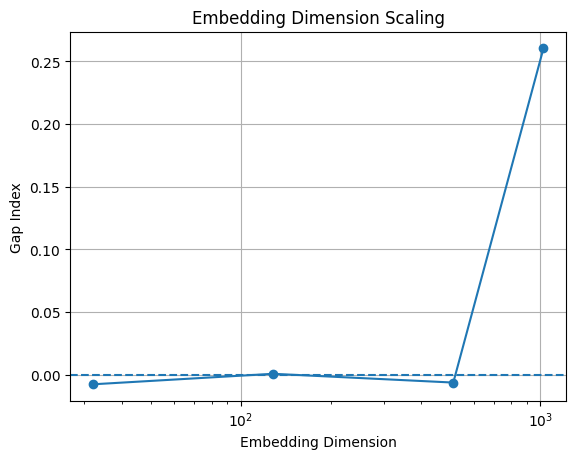

In [2]:
import matplotlib.pyplot as plt

dims = [32, 128, 512, 1024]
gap = [-0.0078, 0.0006, -0.0064, 0.2603]

plt.figure()
plt.plot(dims, gap, marker='o')
plt.axhline(0, linestyle='--')

plt.xscale('log')
plt.xlabel('Embedding Dimension')
plt.ylabel('Gap Index')
plt.title('Embedding Dimension Scaling')

plt.grid(True)
plt.savefig('figure1.png', dpi=300)
plt.show()


=== Table 1: Complexity vs Performance ===
                     Dataset  Classes     Gap
                    CIFAR-10       10  0.3730
               ImageNet-1000     1000  0.0069
ImageNet-1000 (larger model)     1000  0.0161
  ImageNet-1000 (deep model)     1000 -0.0019

=== Table 2: Embedding Dimension Scaling ===
 Embedding Dimension     Gap   Run
                  32 -0.0078 Run 1
                 128  0.0006 Run 1
                 512 -0.0064 Run 1
                1024  0.2603 Run 1
                1024  0.2368 Run 2

=== Table 3: Class Reduction Effect ===
                Setting    Gap
          ImageNet-1000 0.0000
 ImageNet-10 (3 epochs) 0.2196
ImageNet-10 (10 epochs) 0.4404

엑셀 파일 저장 완료: results_tables.xlsx


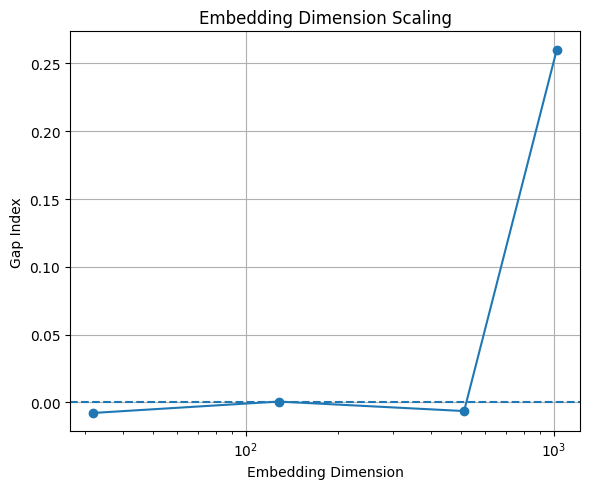

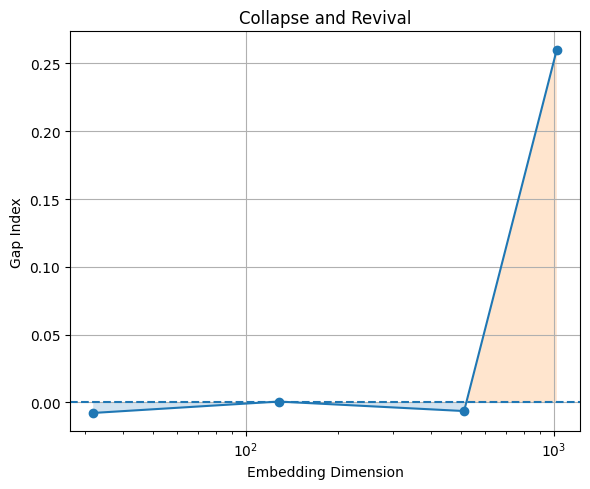

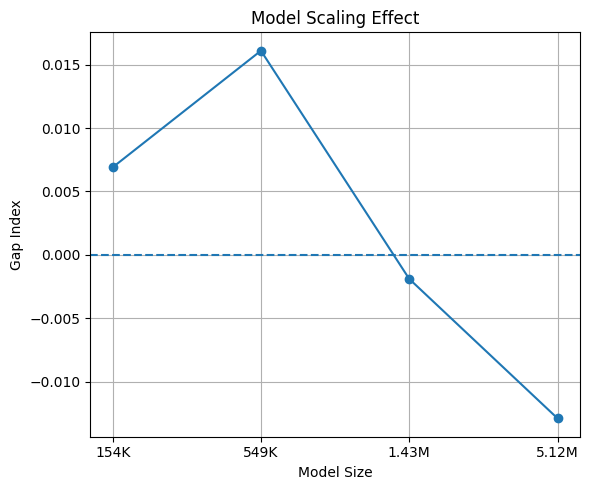


그래프 저장 완료:
- figure1_embedding_scaling.png
- figure2_collapse_revival.png
- figure3_model_scaling.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 데이터 정리
# =========================

# Table 1: Complexity vs Performance
df1 = pd.DataFrame({
    "Dataset": ["CIFAR-10", "ImageNet-1000", "ImageNet-1000 (larger model)", "ImageNet-1000 (deep model)"],
    "Classes": [10, 1000, 1000, 1000],
    "Gap": [0.3730, 0.0069, 0.0161, -0.0019]
})

# Table 2: Embedding Dimension Scaling
df2 = pd.DataFrame({
    "Embedding Dimension": [32, 128, 512, 1024, 1024],
    "Gap": [-0.0078, 0.0006, -0.0064, 0.2603, 0.2368],
    "Run": ["Run 1", "Run 1", "Run 1", "Run 1", "Run 2"]
})

# Table 3: Class Reduction Effect
df3 = pd.DataFrame({
    "Setting": ["ImageNet-1000", "ImageNet-10 (3 epochs)", "ImageNet-10 (10 epochs)"],
    "Gap": [0.0, 0.2196, 0.4404]
})

# =========================
# 2. 표 출력
# =========================
print("\n=== Table 1: Complexity vs Performance ===")
print(df1.to_string(index=False))

print("\n=== Table 2: Embedding Dimension Scaling ===")
print(df2.to_string(index=False))

print("\n=== Table 3: Class Reduction Effect ===")
print(df3.to_string(index=False))

# 엑셀 저장
with pd.ExcelWriter("results_tables.xlsx") as writer:
    df1.to_excel(writer, sheet_name="Complexity_vs_Performance", index=False)
    df2.to_excel(writer, sheet_name="Embedding_Dimension", index=False)
    df3.to_excel(writer, sheet_name="Class_Reduction", index=False)

print("\n엑셀 파일 저장 완료: results_tables.xlsx")

# =========================
# 3. 그래프 1: Embedding Dimension Scaling
# =========================
dims = [32, 128, 512, 1024]
gap = [-0.0078, 0.0006, -0.0064, 0.2603]

plt.figure(figsize=(6,5))
plt.plot(dims, gap, marker='o')
plt.axhline(0, linestyle='--')
plt.xscale('log')
plt.xlabel('Embedding Dimension')
plt.ylabel('Gap Index')
plt.title('Embedding Dimension Scaling')
plt.grid(True)
plt.tight_layout()
plt.savefig("figure1_embedding_scaling.png", dpi=300)
plt.show()

# =========================
# 4. 그래프 2: Collapse and Revival
# =========================
plt.figure(figsize=(6,5))
plt.plot(dims, gap, marker='o')
plt.fill_between(dims[:3], gap[:3], alpha=0.2)
plt.fill_between(dims[2:], gap[2:], alpha=0.2)
plt.axhline(0, linestyle='--')
plt.xscale('log')
plt.xlabel('Embedding Dimension')
plt.ylabel('Gap Index')
plt.title('Collapse and Revival')
plt.grid(True)
plt.tight_layout()
plt.savefig("figure2_collapse_revival.png", dpi=300)
plt.show()

# =========================
# 5. 그래프 3: Model Scaling Effect
# =========================
models = ['154K', '549K', '1.43M', '5.12M']
gap_model = [0.0069, 0.0161, -0.0019, -0.0129]

plt.figure(figsize=(6,5))
plt.plot(models, gap_model, marker='o')
plt.axhline(0, linestyle='--')
plt.xlabel('Model Size')
plt.ylabel('Gap Index')
plt.title('Model Scaling Effect')
plt.grid(True)
plt.tight_layout()
plt.savefig("figure3_model_scaling.png", dpi=300)
plt.show()

print("\n그래프 저장 완료:")
print("- figure1_embedding_scaling.png")
print("- figure2_collapse_revival.png")
print("- figure3_model_scaling.png")

In [1]:
import matplotlib.pyplot as plt

# -----------------------------
# Figure 1: Collapse with complexity
# -----------------------------
datasets = ["MNIST", "CIFAR-10", "ImageNet-10", "ImageNet-100", "ImageNet-1000"]
gap_complexity = [0.82, 0.65, 0.44, 0.14, -0.02]

plt.figure(figsize=(6,4))
plt.plot(datasets, gap_complexity, marker='o')
plt.axhline(0, linestyle='--')
plt.xlabel("Dataset")
plt.ylabel("Gap Index")
plt.title("Representation Collapse with Increasing Complexity")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("fig1_collapse.png", dpi=300)
plt.close()

# -----------------------------
# Figure 2: Recovery by dimension
# -----------------------------
dims = [256, 512, 1024, 2048]
gap_dims = [-0.15, -0.02, 0.26, 0.23]

plt.figure(figsize=(6,4))
plt.plot(dims, gap_dims, marker='o')
plt.axhline(0, linestyle='--')
plt.xlabel("Embedding Dimension")
plt.ylabel("Gap Index")
plt.title("Dimensionality-Induced Recovery")
plt.tight_layout()
plt.savefig("fig2_recovery.png", dpi=300)
plt.close()

# -----------------------------
# Figure 3: Saturation effect
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(dims, gap_dims, marker='o')
plt.axhline(0, linestyle='--')
plt.xlabel("Embedding Dimension")
plt.ylabel("Gap Index")
plt.title("Saturation Beyond Critical Dimension")
plt.tight_layout()
plt.savefig("fig3_saturation.png", dpi=300)
plt.close()

print("Saved:")
print(" - fig1_collapse.png")
print(" - fig2_recovery.png")
print(" - fig3_saturation.png")

Saved:
 - fig1_collapse.png
 - fig2_recovery.png
 - fig3_saturation.png


In [4]:
import os
import random
import numpy as np
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, Sampler
from torchvision import datasets, transforms, models

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# =========================================================
# 0. 설정
# =========================================================
DATA_ROOT = "/kaggle/input/datasets/ifigotin/imagenetmini-1000/imagenet-mini"   # 예: "/kaggle/input/imagenet-subset"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 2
EPOCHS = 10
LR = 1e-4
SEEDS = [42, 43, 44]
EMBED_DIMS = [512, 1024]
KNN_K = 5
TEMPERATURE = 0.07

# 먼저 100클래스로 검증 추천
MAX_CLASSES = 100          # 처음엔 100으로, 잘 되면 1000으로 올려라
MAX_TRAIN_PER_CLASS = 100
MAX_VAL_PER_CLASS = 50

# SupCon용 balanced batch
N_CLASSES_PER_BATCH = 16   # 한 배치에 들어갈 클래스 수
N_SAMPLES_PER_CLASS = 4    # 클래스당 샘플 수
BATCH_SIZE = N_CLASSES_PER_BATCH * N_SAMPLES_PER_CLASS

print("DEVICE:", DEVICE)
print("BATCH_SIZE:", BATCH_SIZE)

# =========================================================
# 1. 유틸
# =========================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def get_targets_from_dataset(dataset):
    """
    dataset이 ImageFolder 또는 Subset일 때 labels 추출
    """
    if isinstance(dataset, Subset):
        base_dataset = dataset.dataset
        if hasattr(base_dataset, "targets"):
            base_targets = base_dataset.targets
        else:
            base_targets = [s[1] for s in base_dataset.samples]
        return [base_targets[i] for i in dataset.indices]
    else:
        if hasattr(dataset, "targets"):
            return dataset.targets
        else:
            return [s[1] for s in dataset.samples]

def build_subset_by_class(dataset, max_classes=None, max_per_class=None):
    targets = get_targets_from_dataset(dataset)

    class_to_indices = defaultdict(list)
    for idx, y in enumerate(targets):
        class_to_indices[y].append(idx)

    classes = sorted(class_to_indices.keys())
    if max_classes is not None:
        classes = classes[:max_classes]

    selected = []
    for c in classes:
        idxs = class_to_indices[c]
        if max_per_class is not None:
            idxs = idxs[:max_per_class]
        selected.extend(idxs)

    return Subset(dataset, selected)

def pairwise_gap(embeddings, labels, max_samples=3000):
    n = len(embeddings)
    if n > max_samples:
        idx = np.random.choice(n, max_samples, replace=False)
        embeddings = embeddings[idx]
        labels = labels[idx]

    norms = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-12
    embeddings = embeddings / norms

    same_dists = []
    diff_dists = []

    for i in range(len(embeddings)):
        js = np.random.choice(len(embeddings), size=min(100, len(embeddings)), replace=False)
        for j in js:
            if i == j:
                continue
            d = np.linalg.norm(embeddings[i] - embeddings[j])
            if labels[i] == labels[j]:
                same_dists.append(d)
            else:
                diff_dists.append(d)

    same_mean = float(np.mean(same_dists)) if same_dists else 0.0
    diff_mean = float(np.mean(diff_dists)) if diff_dists else 0.0
    gap = diff_mean - same_mean
    return gap, same_mean, diff_mean

# =========================================================
# 2. Class-balanced batch sampler
# =========================================================
class ClassBalancedBatchSampler(Sampler):
    def __init__(self, dataset, n_classes=16, n_samples=4):
        self.dataset = dataset
        self.n_classes = n_classes
        self.n_samples = n_samples
        self.batch_size = n_classes * n_samples

        targets = get_targets_from_dataset(dataset)

        self.class_to_indices = defaultdict(list)
        for idx, y in enumerate(targets):
            self.class_to_indices[y].append(idx)

        # 샘플 수가 부족한 클래스 제거
        self.classes = [c for c, idxs in self.class_to_indices.items() if len(idxs) >= self.n_samples]

        for c in self.classes:
            random.shuffle(self.class_to_indices[c])

    def __iter__(self):
        # epoch마다 계속 배치를 생성
        num_batches = len(self.dataset) // self.batch_size

        for _ in range(num_batches):
            selected_classes = random.sample(self.classes, self.n_classes)
            batch = []

            for c in selected_classes:
                idxs = random.sample(self.class_to_indices[c], self.n_samples)
                batch.extend(idxs)

            yield batch

    def __len__(self):
        return len(self.dataset) // self.batch_size

# =========================================================
# 3. SupCon Loss
# =========================================================
class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device = features.device
        batch_size = features.shape[0]

        labels = labels.view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)

        anchor_dot_contrast = torch.div(torch.matmul(features, features.T), self.temperature)

        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        logits_mask = torch.ones_like(mask) - torch.eye(batch_size, device=device)
        mask = mask * logits_mask

        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)

        mask_sum = mask.sum(dim=1)
        mean_log_prob_pos = (mask * log_prob).sum(dim=1) / (mask_sum + 1e-12)

        loss = -mean_log_prob_pos.mean()
        return loss

# =========================================================
# 4. 데이터셋
# =========================================================
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset_full = datasets.ImageFolder(TRAIN_DIR, transform=transform_train)
val_dataset_full   = datasets.ImageFolder(VAL_DIR, transform=transform_val)

train_dataset = build_subset_by_class(
    train_dataset_full,
    max_classes=MAX_CLASSES,
    max_per_class=MAX_TRAIN_PER_CLASS
)
val_dataset = build_subset_by_class(
    val_dataset_full,
    max_classes=MAX_CLASSES,
    max_per_class=MAX_VAL_PER_CLASS
)

balanced_sampler = ClassBalancedBatchSampler(
    train_dataset,
    n_classes=N_CLASSES_PER_BATCH,
    n_samples=N_SAMPLES_PER_CLASS
)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=balanced_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

num_classes = MAX_CLASSES if MAX_CLASSES is not None else len(train_dataset_full.classes)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Num classes:", num_classes)

# =========================================================
# 5. 모델
# =========================================================
class ResNet18Embedding(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        backbone = models.resnet18(weights=None)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.embed = nn.Linear(in_features, emb_dim)

    def forward(self, x):
        feat = self.backbone(x)
        z = self.embed(feat)
        z = F.normalize(z, dim=1)
        return z

# =========================================================
# 6. 학습 / 평가
# =========================================================
def train_one_model(seed, emb_dim):
    set_seed(seed)

    model = ResNet18Embedding(emb_dim=emb_dim).to(DEVICE)
    criterion = SupConLoss(temperature=TEMPERATURE)
    optimizer = optim.Adam(model.parameters(), lr=LR)

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        total = 0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            z = model(images)
            loss = criterion(z, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            total += images.size(0)

        print(f"[Seed {seed}] [D={emb_dim}] Epoch {epoch+1}/{EPOCHS} Loss={total_loss/total:.4f}")

    return model

@torch.no_grad()
def extract_embeddings(model, loader):
    model.eval()
    all_emb = []
    all_labels = []

    for images, labels in loader:
        images = images.to(DEVICE)
        z = model(images)
        all_emb.append(z.cpu().numpy())
        all_labels.append(labels.numpy())

    all_emb = np.concatenate(all_emb, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_emb, all_labels

def evaluate_with_knn_and_gap(model):
    train_emb, train_labels = extract_embeddings(model, train_loader)
    val_emb, val_labels = extract_embeddings(model, val_loader)

    knn = KNeighborsClassifier(n_neighbors=KNN_K)
    knn.fit(train_emb, train_labels)
    pred = knn.predict(val_emb)
    knn_acc = accuracy_score(val_labels, pred)

    gap, same_mean, diff_mean = pairwise_gap(val_emb, val_labels)

    return {
        "gap": gap,
        "same_mean": same_mean,
        "diff_mean": diff_mean,
        "knn_acc": knn_acc
    }

# =========================================================
# 7. 전체 실행
# =========================================================
results = []

for emb_dim in EMBED_DIMS:
    dim_metrics = []

    for seed in SEEDS:
        print("=" * 80)
        print(f"Start: emb_dim={emb_dim}, seed={seed}")
        model = train_one_model(seed, emb_dim)
        metrics = evaluate_with_knn_and_gap(model)
        metrics["seed"] = seed
        metrics["emb_dim"] = emb_dim
        dim_metrics.append(metrics)
        results.append(metrics)

        print(f"[Seed {seed}] [D={emb_dim}] "
              f"GAP={metrics['gap']:.4f} "
              f"same={metrics['same_mean']:.4f} "
              f"diff={metrics['diff_mean']:.4f} "
              f"kNN={metrics['knn_acc']:.4f}")

    gap_mean = np.mean([m["gap"] for m in dim_metrics])
    gap_std  = np.std([m["gap"] for m in dim_metrics])
    knn_mean = np.mean([m["knn_acc"] for m in dim_metrics])
    knn_std  = np.std([m["knn_acc"] for m in dim_metrics])

    print("-" * 80)
    print(f"[SUMMARY] D={emb_dim}")
    print(f"Gap     : {gap_mean:.4f} ± {gap_std:.4f}")
    print(f"k-NN Acc: {knn_mean:.4f} ± {knn_std:.4f}")
    print("-" * 80)

print("\n=== Final Table (for paper) ===")
print("EmbeddingDim\tGapMean\tGapStd\tkNNMean\tkNNStd")

for emb_dim in EMBED_DIMS:
    dim_metrics = [r for r in results if r["emb_dim"] == emb_dim]
    gap_mean = np.mean([m["gap"] for m in dim_metrics])
    gap_std  = np.std([m["gap"] for m in dim_metrics])
    knn_mean = np.mean([m["knn_acc"] for m in dim_metrics])
    knn_std  = np.std([m["knn_acc"] for m in dim_metrics])

    print(f"{emb_dim}\t{gap_mean:.4f}\t{gap_std:.4f}\t{knn_mean:.4f}\t{knn_std:.4f}")

DEVICE: cuda
BATCH_SIZE: 64
Train size: 3082
Val size: 344
Num classes: 100
Start: emb_dim=512, seed=42
[Seed 42] [D=512] Epoch 1/10 Loss=4.0921
[Seed 42] [D=512] Epoch 2/10 Loss=4.0474
[Seed 42] [D=512] Epoch 3/10 Loss=4.0130
[Seed 42] [D=512] Epoch 4/10 Loss=3.9804
[Seed 42] [D=512] Epoch 5/10 Loss=3.9782
[Seed 42] [D=512] Epoch 6/10 Loss=3.9167
[Seed 42] [D=512] Epoch 7/10 Loss=3.8461
[Seed 42] [D=512] Epoch 8/10 Loss=3.8439
[Seed 42] [D=512] Epoch 9/10 Loss=3.7201
[Seed 42] [D=512] Epoch 10/10 Loss=3.6326
[Seed 42] [D=512] GAP=0.0759 same=0.4799 diff=0.5558 kNN=0.0610
Start: emb_dim=512, seed=43
[Seed 43] [D=512] Epoch 1/10 Loss=4.0901
[Seed 43] [D=512] Epoch 2/10 Loss=4.0340
[Seed 43] [D=512] Epoch 3/10 Loss=4.0040
[Seed 43] [D=512] Epoch 4/10 Loss=3.9812
[Seed 43] [D=512] Epoch 5/10 Loss=3.9411
[Seed 43] [D=512] Epoch 6/10 Loss=3.8973
[Seed 43] [D=512] Epoch 7/10 Loss=3.8658
[Seed 43] [D=512] Epoch 8/10 Loss=3.7745
[Seed 43] [D=512] Epoch 9/10 Loss=3.7360
[Seed 43] [D=512] Epoch 